# Imports

In [1]:
%load_ext autoreload
%autoreload 2
import sys

sys.path.append('../../')

In [2]:
import glob
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import scipy
import pandas as pd
import seaborn as sns

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, cross_validate, StratifiedKFold

from dataclasses import dataclass

import pyaldata as pyal

import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.reports as reports
import tools.kinematics as kin

from tqdm import tqdm
import pickle

from joblib import Parallel, delayed

import numpy as np

In [4]:
SESSIONS = [
    # "M061_2025_03_04_10_00",
    # "M061_2025_03_05_14_00",
    # "M061_2025_03_06_14_00",
    # "M063_2025_03_13_14_00",
    # "M063_2025_03_14_15_30",
    # "M062_2025_03_20_14_00",
    # "M062_2025_03_21_14_00",
    # "M078_2025_08_06_15_00",
    # "M086_2025_12_10_15_00",
    "M103_2026_02_18_15_30",
    # "M103_2026_02_19_15_30",
    # "M106_2026_02_25_15_00",
    # "M106_2026_02_26_16_00",
]


In [5]:
df_tr, dstrb_idx = dsp.load_and_process_session(SESSIONS[0], std=0.05)
perturb_td = pyal.restrict_to_interval(
    df_tr,
    start_point_name="idx_sol_on",
    rel_start=-200,
    rel_end=300,
)
perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)


fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
['all_spikes', 'CP_spikes', 'MOp_spikes', 'VAL_spikes', 'SSp_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(


Resulting all_spikes ephys data shape is (NxT): (15, 48000)
Resulting CP_spikes ephys data shape is (NxT): (267, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (190, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (126, 48000)
Skipped 8 trials
Otsu immobility threshold: 6.6387
Dropped 70 of 497 rows (14.08%).


/tmp/ipykernel_4124089/1430965440.py:2: UserWarning: Dropping 1 trials because of invalid time indexing. For more information, try warn_per_trial=True
  perturb_td = pyal.restrict_to_interval(


In [13]:
for area in Params.areas:
    pr = dim.pca_pr(np.concatenate(perturb_td[f'{area}_rates'].values))
    print(f'{area}: {pr}')

MOp: 22.25288943741063
SSp: 34.68811742643329
CP: 31.114374185286753
VAL: 13.404579001202162


In [ ]:
area_x = 'MOp'
area_y = 'SSp'
origin_rank=30

td_potent_null = subspaces.compute_potent_null_td(
    td_=perturb_td_shuff,
    signal_x=f'{area_x}_rates_pca',
    signal_y=f'{area_y}_rates_pca',
    origin_rank=origin_rank,
    target_rank=30,
    n_iter=2
)

Computing MOp_rates_pca -> SSp_rates_pca potent and null subspaces
Prediction R2 = 0.2889. Optimal rank: 4
Using 2 iterations...
	Iter: 1. Prediction R2 = 0.0000
Iteration number: 1. R2 below 0.01, breaking
	Final Prediction R2 = 0.0000
Diagnostics:
	Total MOp_rates_pca var:         8840.58
	Fraction Potent (dim: 4) var:    0.346
	Fraction Null init var:          0.034
	Fraction MOp_rates_pca var:      0.381


In [7]:
from sklearn.model_selection import StratifiedKFold

def majority_class_chance_levels_from_counts(counts):
    """
    counts_dict: {class_label: count, ...}
    Returns:
      N, majority_chance, prior_weighted_chance, uniform_chance
    """
    N = counts.sum()

    majority_chance = counts.max() / N

    return majority_chance

def naive_opt_alpha(alpha_range, cv_scores):
    """
    Select the alpha value with the highest cross-validated test score

    Parameters
    ----------
    alpha_range : array-like
        candidate alpha values
    cv_scores : array-like
        cross-validated test scores corresponding
        to the values in alpha_range

    Returns
    -------
    optimal alpha : float
    """
    means = [np.mean(sc) for sc in cv_scores]
    return alpha_range[np.argmax(means)]


def opt_ridge_alpha(X, y, n_alpha=50, cv=KFold(5), scorer=decode.get_custom_scorer()):
    candidate_alphas = np.logspace(-4, 2, n_alpha)
    cv_scores = [
        cross_val_score(Ridge(alpha, solver='lsqr'), X, y, cv=cv, scoring=scorer)
        for alpha in tqdm(candidate_alphas)
    ]

    return naive_opt_alpha(candidate_alphas, cv_scores)

def decode_perturb_score_potent_null(td, area_origin, area_target, k=3, window=100, shuffle=False, rnd=None,
                                     opt_alpha=True, step_bin=2, scorer=decode.get_custom_scorer()):
    if shuffle:
        rnd = 42
    y = td.disturb_sum.values

    labels = [
        # f'{area_origin}_rates_pca',
        f'{area_origin}_rates_pca_null_{area_target}_rates_pca',
        f'{area_origin}_rates_pca_potent_{area_target}_rates_pca',
        # 'lower_bound'
    ]
    scores_list, y_preds_list = [], []
    for label in labels:
        if label == 'lower_bound':
            rng = np.random.default_rng(seed=42)
            perm = rng.permutation(y.shape[0])
            y = y[perm]
            label = labels[2]
        X = np.stack(td[label].values)
        if opt_alpha:
            alpha=opt_ridge_alpha(X.reshape(X.shape[0], -1), y, cv=KFold(shuffle=shuffle, random_state=rnd, n_splits=k))
            print(f'Alpha param {alpha:.3f}')
        else:
            alpha=0.01
        scores, times, y_preds = decode.decoding_moving_window_no_time_concat(
            Ridge(alpha, solver='lsqr'),
            X,
            y,
            cv=KFold(shuffle=shuffle, random_state=rnd, n_splits=k),
            scorer=scorer,
            window_length_bin=window,
            step_bin=step_bin
        )
        scores_list.append(scores)
        y_preds_list.append(y_preds)

    
    return scores_list, times, y_preds_list

def decode_sol_dir_potent_null(td, area_origin, area_target, k=3, window=100, shuffle=False, rnd=None):
    if shuffle:
        rnd = 42
    y = np.array(td.values_Sol_direction.values.tolist())
    classes, counts = np.unique(y, return_counts=True)
    chance = majority_class_chance_levels_from_counts(counts)
    labels = [
        f'{area_origin}_rates_pca',
        f'{area_origin}_rates_pca_null_{area_target}_rates_pca',
        f'{area_origin}_rates_pca_potent_{area_target}_rates_pca',
        # 'lower_bound'
    ]
    scores_list = []
    for label in labels:
        if label == 'lower_bound':
            rng = np.random.default_rng(seed=42)
            perm = rng.permutation(y.shape[0])
            y = y[perm]
            label = labels[2]
        X = np.stack(td[label].values)
        scores, times = decode.moving_window_decoding(
            X,
            y,
            cv=StratifiedKFold(n_splits=k, shuffle=shuffle, random_state=rnd),
            window_length_bin=window,
            step_bin=2,
        )
        scores_list.append(scores)

    
    return scores_list, times, chance

In [54]:
area_a ='MOp'
area_b = 'CP'
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")

window = 5
shuffle = True
opt_alpha = False
step_bin = 2

td_potent_null_dropped = dsp.drop_trials_sem_crosses_zero(td_potent_null, std=True)


td_potent_null_ord = (
    td_potent_null_dropped
    .sort_values(by='trial_id')
    .reset_index(drop=True)
)

scores_perturb, times_disturb, y_preds = decode_perturb_score_potent_null(
    td_potent_null_ord, 
    area_a, 
    area_b, 
    window=window,
    k=5,
    shuffle=shuffle,
    opt_alpha=opt_alpha,
    # scorer=vw_r2_scorer,
    # rnd=40
    )

scores_dir, times_dir, chance = decode_sol_dir_potent_null(
    td_potent_null_ord, area_a, area_b, 
    window=20,
    k=5,
    shuffle=shuffle,
)

  drop_trials_sem_crosses_zero: by SEM: 167  |  by value: 309  |  kept: 151/325 (46.5%)


  0%|          | 0/249 [00:00<?, ?it/s]

100%|██████████| 241/241 [00:02<00:00, 103.87it/s]


In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(6, 10), sharey='none')
vizutils.shaded_errorbar(ax[0], times_disturb-2, scores_perturb[0], label=f'null {area_b}')
vizutils.shaded_errorbar(ax[0], times_disturb-2, scores_perturb[1], label=f'potent {area_b}')
ax[0].legend()
window=5
vizutils.shaded_errorbar(ax[1], times_dir-2, scores_dir[0], label=f'full')
vizutils.shaded_errorbar(ax[1], times_dir-2, scores_dir[1], label=f'null {area_b}')
vizutils.shaded_errorbar(ax[1], times_dir-2, scores_dir[2], label=f'potent {area_b}')


ax[1].set_title(f'Sol direction')
ax[1].axvline(0, color='k', linestyle='dashed', label='perturbation')
ax[1].axhline(1/12, color='r', linestyle='dashed', label='chance')

ax[1].legend()
ax[1].set_xlim(-0.5, 1.5)
ax[1].set_ylim(0, 0.55)

plt.suptitle(f'Trials. {window * 0.01} s. ' 
             f'Shuffle: {shuffle}. Opt-alpha: {opt_alpha}', y=0.9)

In [ ]:
y = td_potent_null_ord.disturb_sum.values
fig, axs = plt.subplots(1, 2, figsize=(9, 4), sharex=True, sharey=True)

sns.regplot(
    x=y,
    y=y_preds[1][40],
    ax=axs[0],
    truncate=False,
    scatter_kws=dict(color=colors.MOp_light, alpha=0.6),
    line_kws=dict(linewidth=2, color=colors.MOp),
)
axs[0].set_xlabel('Actual disturbance')
axs[0].set_ylabel('Predicted disturbance')
axs[0].set_aspect('equal')

sns.regplot(
    x=y,
    y=y_preds[1][127],
    ax=axs[1],
    truncate=False,
    scatter_kws=dict(color=colors.MOp_light, alpha=0.6),
    line_kws=dict(linewidth=2, color=colors.MOp),
)
axs[1].set_xlabel('Actual disturbance')
axs[1].set_ylabel('Predicted disturbance')
axs[1].set_aspect('equal')

r = np.corrcoef(y, y_preds[1][127])[0, 1]
print(r)

# Trial averaged activity?

In [115]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, KFold

shuffle=False
alpha=0.01
window = (200, 400)

td_potent_null_dropped = dsp.drop_trials_sem_crosses_zero(td_potent_null, std=True)


td_potent_null_ord = (
    td_potent_null_dropped
    .sort_values(by='trial_id')
    .reset_index(drop=True)
)



full_arr = np.stack(td_potent_null_ord[f'{area_x}_rates_pca'].values)[:, window[0]:window[1], :origin_rank]
full_arr = full_arr.mean(1)

potent_arr = np.stack(td_potent_null_ord[f'{area_x}_rates_pca_potent_{area_y}_rates_pca'].values)[:, window[0]:window[1], :]
potent_arr = potent_arr.mean(1)

null_arr = np.stack(td_potent_null_ord[f'{area_x}_rates_pca_null_{area_y}_rates_pca'].values)[:, window[0]:window[1], :]
null_arr = null_arr.mean(1)

rng = np.random.default_rng(seed=42)
perm = rng.permutation(td_potent_null_ord.disturb_sum.values.shape[0])

# Disturbance decoding
y_dist = td_potent_null_ord.disturb_sum.values
r2s_full    = cross_val_score(Ridge(alpha), full_arr,   y_dist,       scoring=decode.get_custom_scorer(), cv=KFold(5, shuffle=shuffle))
r2s_potent  = cross_val_score(Ridge(alpha), potent_arr, y_dist,       scoring=decode.get_custom_scorer(), cv=KFold(5, shuffle=shuffle))
r2s_null    = cross_val_score(Ridge(alpha), null_arr,   y_dist,       scoring=decode.get_custom_scorer(), cv=KFold(5, shuffle=shuffle))
r2s_lower_bound = cross_val_score(Ridge(alpha), potent_arr, y_dist[perm], scoring=decode.get_custom_scorer(), cv=KFold(5, shuffle=shuffle))

print(f'Disturbance — full: {r2s_full.mean():.4f}  potent: {r2s_potent.mean():.4f}  null: {r2s_null.mean():.4f}  lb: {r2s_lower_bound.mean():.4f}')


window = (200, 300)

full_arr = np.stack(td_potent_null_ord[f'{area_x}_rates_pca'].values)[:, window[0]:window[1], :]
full_arr = full_arr.reshape(full_arr.shape[0], -1)

potent_arr = np.stack(td_potent_null_ord[f'{area_x}_rates_pca_potent_{area_y}_rates_pca'].values)[:, window[0]:window[1], :]
potent_arr = potent_arr.reshape(potent_arr.shape[0], -1)

null_arr = np.stack(td_potent_null_ord[f'{area_x}_rates_pca_null_{area_y}_rates_pca'].values)[:, window[0]:window[1], :17]
null_arr = null_arr.reshape(null_arr.shape[0], -1)

rng = np.random.default_rng(seed=42)
perm = rng.permutation(td_potent_null_ord.disturb_sum.values.shape[0])
# Direction decoding
y_dir = np.array(td_potent_null_ord.values_Sol_direction.values.tolist())

perm_dir = rng.permutation(y_dir.shape[0])
r2s_full_dir    = cross_val_score(GaussianNB(), full_arr,   y_dir,           scoring='accuracy', cv=StratifiedKFold(4, shuffle=shuffle))
r2s_potent_dir  = cross_val_score(GaussianNB(), potent_arr, y_dir,           scoring='accuracy', cv=StratifiedKFold(4, shuffle=shuffle))
r2s_null_dir    = cross_val_score(GaussianNB(), null_arr,   y_dir,           scoring='accuracy', cv=StratifiedKFold(4, shuffle=shuffle))
r2s_lower_bound_dir = cross_val_score(GaussianNB(), potent_arr, y_dir[perm_dir], scoring='' \
'accuracy', cv=StratifiedKFold(4, shuffle=shuffle))

print(f'Direction     — full: {r2s_full_dir.mean():.4f}  potent: {r2s_potent_dir.mean():.4f}  null: {r2s_null_dir.mean():.4f}  lb: {r2s_lower_bound_dir.mean():.4f}')

  drop_trials_sem_crosses_zero: by SEM: 207  |  by value: 423  |  kept: 206/424 (48.6%)
Disturbance — full: 0.2006  potent: 0.4193  null: 0.0316  lb: 0.0257
Direction     — full: 0.2861  potent: 0.2517  null: 0.2763  lb: 0.0877


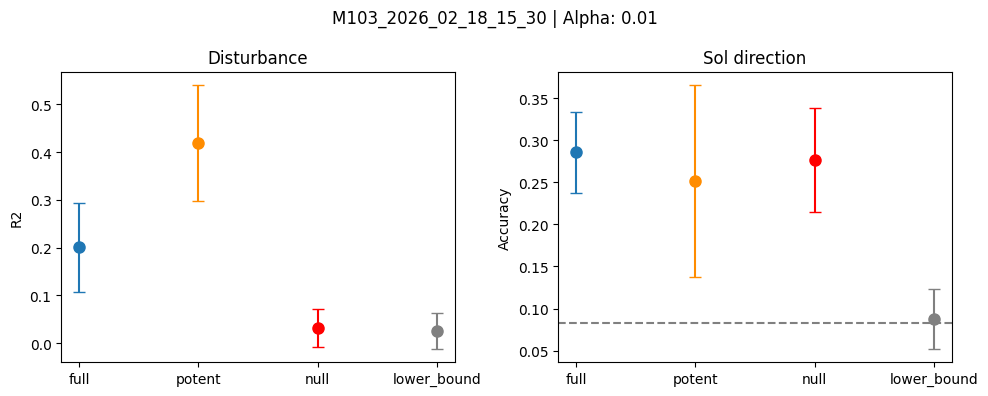

In [116]:
labels = ['full', 'potent', 'null', 'lower_bound']
clrs   = ['tab:blue', 'darkorange', 'red', 'gray']

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

data = [
    (axs[0], 'Disturbance', [r2s_full, r2s_potent, r2s_null, r2s_lower_bound], 'R2', ),
    (axs[1], 'Sol direction', [r2s_full_dir, r2s_potent_dir, r2s_null_dir, r2s_lower_bound_dir], 'Accuracy'),
]

for ax, title, r2s_list, ylabel in data:
    for i, (lbl, r2s, c) in enumerate(zip(labels, r2s_list, clrs)):
        ax.errorbar(i, r2s.mean(), yerr=r2s.std(), color=c, fmt='o', markersize=8, capsize=4, label=lbl)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if ylabel=='Accuracy':
        ax.axhline(1/12, color='gray', linestyle='dashed')
plt.suptitle(f'{SESSIONS[0]} | Alpha: {alpha}')
plt.tight_layout()

In [21]:
_potent_var

1547.6555613141036

  drop_trials_sem_crosses_zero: by SEM: 207  |  by value: 423  |  kept: 206/424 (48.6%)


Full   (25 PCs):  var = 5882.6
Potent ( 8 dims): var = 2765.0
Null   (48 dims):  var = 3011.2
Null trimmed (44 dims): var = 2756.5  (diff from potent = 8.5)

Disturbance R²:
  Full (25 PCs, var=5883): 0.338 ± 0.070
  Potent:         0.374 ± 0.148
  Null (raw):     0.019 ± 0.024
  Null (trimmed): 0.017 ± 0.018
  Lower bound:    0.010 ± 0.010

Direction accuracy:
  Full (25 PCs, var=5883): 0.349 ± 0.035
  Potent:         0.242 ± 0.063
  Null (raw):     0.330 ± 0.057
  Null (trimmed): 0.330 ± 0.054
  Lower bound:    0.116 ± 0.036


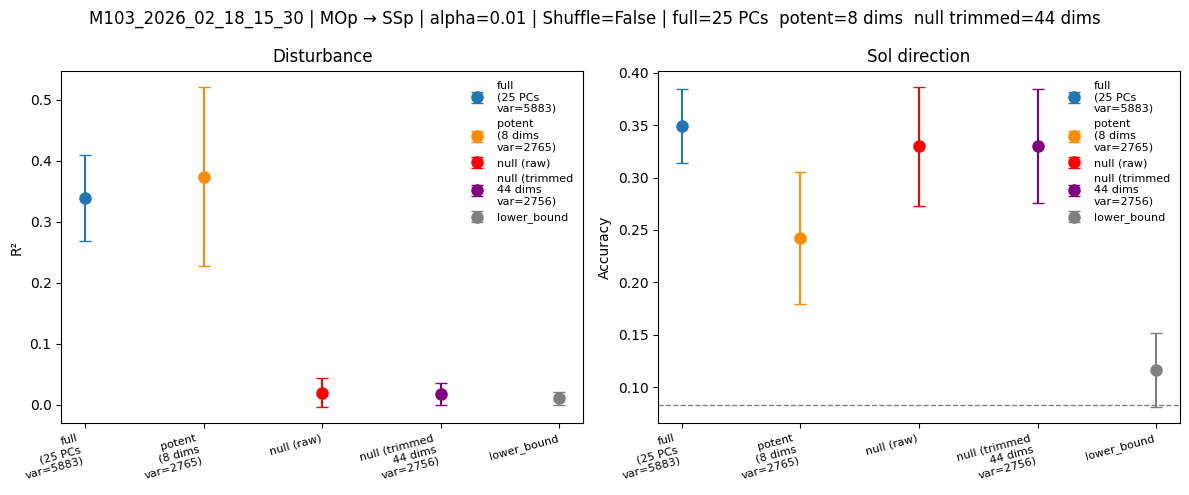

In [173]:
# ── Self-contained decoding: full / potent / null (raw) / null (trimmed) ──────
# Disturbance: window-averaged (mean over time)
# Direction:   flattened (time × dims) to preserve temporal structure
# Null trimming: find k null dims whose variance matches potent variance
# Full trimming: find k full dims whose variance matches potent variance

from tools.subspaces.utils import variance_in_subspace
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, KFold
td_potent_null_dropped = dsp.drop_trials_sem_crosses_zero(td_potent_null, std=True)


td_potent_null_ord = (
    td_potent_null_dropped
    .sort_values(by='trial_id')
    .reset_index(drop=True)
)



# ── parameters ────────────────────────────────────────────────────────────────
_alpha        = 0.01
_shuffle      = False
_window_dist  = (200, 400)
_window_dir   = (200, 300)
_N_FULL_PCS   = 25   # ← number of PCs to use for the full space

_full_col   = f'{area_x}_rates_pca'
_potent_col = f'{area_x}_rates_pca_potent_{area_y}_rates_pca'
_null_col   = f'{area_x}_rates_pca_null_{area_y}_rates_pca'

_td = td_potent_null_ord

# ── targets ───────────────────────────────────────────────────────────────────
_y_dist = _td.disturb_sum.values
_y_dir  = np.array(_td.values_Sol_direction.values.tolist())
_rng    = np.random.default_rng(seed=42)
_perm_dist = _rng.permutation(len(_y_dist))
_perm_dir  = _rng.permutation(len(_y_dir))

# ── find k via variance sweep on full concatenated time series ────────────────
_X_full   = np.concatenate(_td[_full_col].values)[:, :_N_FULL_PCS]
_X_potent = np.concatenate(_td[_potent_col].values)
_X_null   = np.concatenate(_td[_null_col].values)

n_full   = _X_full.shape[1]
n_potent = _X_potent.shape[1]
n_null   = _X_null.shape[1]

_var_potent = variance_in_subspace(_X_potent, np.eye(n_potent))
_var_full   = variance_in_subspace(_X_full,   np.eye(n_full))

# sweep null dims to match potent variance
_null_vars = np.array([
    variance_in_subspace(_X_null, np.eye(n_null)[:, :k])
    for k in range(1, n_null + 1)
])
_n_keep      = int(np.argmin(np.abs(_null_vars - _var_potent))) + 1
_var_trimmed = _null_vars[_n_keep - 1]

print(f'Full   ({n_full:2d} PCs):  var = {_var_full:.1f}')
print(f'Potent ({n_potent:2d} dims): var = {_var_potent:.1f}')
print(f'Null   ({n_null:2d} dims):  var = {_null_vars[-1]:.1f}')
print(f'Null trimmed ({_n_keep:2d} dims): var = {_var_trimmed:.1f}  '
      f'(diff from potent = {abs(_var_trimmed - _var_potent):.1f})')

# ── build disturbance arrays (mean over time) ─────────────────────────────────
_full_dist   = np.stack(_td[_full_col].values)[:,   _window_dist[0]:_window_dist[1], :_N_FULL_PCS].mean(1)
_potent_dist = np.stack(_td[_potent_col].values)[:, _window_dist[0]:_window_dist[1], :].mean(1)
_null_dist   = np.stack(_td[_null_col].values)[:,   _window_dist[0]:_window_dist[1], :].mean(1)
_null_dist_t = np.stack(_td[_null_col].values)[:,   _window_dist[0]:_window_dist[1], :_n_keep].mean(1)

# ── build direction arrays (trim dims, then flatten time) ─────────────────────
def _flatten(arr): return arr.reshape(arr.shape[0], -1)

_full_dir   = _flatten(np.stack(_td[_full_col].values)[:,   _window_dir[0]:_window_dir[1], :_N_FULL_PCS])
_potent_dir = _flatten(np.stack(_td[_potent_col].values)[:, _window_dir[0]:_window_dir[1], :])
_null_dir   = _flatten(np.stack(_td[_null_col].values)[:,   _window_dir[0]:_window_dir[1], :])
_null_dir_t = _flatten(np.stack(_td[_null_col].values)[:,   _window_dir[0]:_window_dir[1], :_n_keep])

# ── decode ────────────────────────────────────────────────────────────────────
_cv_dist = KFold(5, shuffle=_shuffle)
_cv_dir  = StratifiedKFold(4, shuffle=_shuffle)
_scorer  = decode.get_custom_scorer()

def _r2(X, y, cv=_cv_dist):
    return cross_val_score(Ridge(_alpha), X, y, scoring=_scorer, cv=cv)

def _acc(X, y, cv=_cv_dir):
    return cross_val_score(GaussianNB(), X, y, scoring='accuracy', cv=cv)

r2s_full        = _r2(_full_dist,   _y_dist)
r2s_potent      = _r2(_potent_dist, _y_dist)
r2s_null        = _r2(_null_dist,   _y_dist)
r2s_null_t      = _r2(_null_dist_t, _y_dist)
r2s_lower_bound = _r2(_potent_dist, _y_dist[_perm_dist])

r2s_full_dir        = _acc(_full_dir,   _y_dir)
r2s_potent_dir      = _acc(_potent_dir, _y_dir)
r2s_null_dir        = _acc(_null_dir,   _y_dir)
r2s_null_dir_t      = _acc(_null_dir_t, _y_dir)
r2s_lower_bound_dir = _acc(_potent_dir, _y_dir[_perm_dir])

print(f'\nDisturbance R²:')
print(f'  Full ({n_full} PCs, var={_var_full:.0f}): {r2s_full.mean():.3f} ± {r2s_full.std():.3f}')
print(f'  Potent:         {r2s_potent.mean():.3f} ± {r2s_potent.std():.3f}')
print(f'  Null (raw):     {r2s_null.mean():.3f} ± {r2s_null.std():.3f}')
print(f'  Null (trimmed): {r2s_null_t.mean():.3f} ± {r2s_null_t.std():.3f}')
print(f'  Lower bound:    {r2s_lower_bound.mean():.3f} ± {r2s_lower_bound.std():.3f}')
print(f'\nDirection accuracy:')
print(f'  Full ({n_full} PCs, var={_var_full:.0f}): {r2s_full_dir.mean():.3f} ± {r2s_full_dir.std():.3f}')
print(f'  Potent:         {r2s_potent_dir.mean():.3f} ± {r2s_potent_dir.std():.3f}')
print(f'  Null (raw):     {r2s_null_dir.mean():.3f} ± {r2s_null_dir.std():.3f}')
print(f'  Null (trimmed): {r2s_null_dir_t.mean():.3f} ± {r2s_null_dir_t.std():.3f}')
print(f'  Lower bound:    {r2s_lower_bound_dir.mean():.3f} ± {r2s_lower_bound_dir.std():.3f}')

# ── plot ──────────────────────────────────────────────────────────────────────
labels = [f'full\n({n_full} PCs\nvar={_var_full:.0f})',
          f'potent\n({n_potent} dims\nvar={_var_potent:.0f})',
          'null (raw)',
          f'null (trimmed\n{_n_keep} dims\nvar={_var_trimmed:.0f})',
          'lower_bound']
clrs   = ['tab:blue', 'darkorange', 'red', 'purple', 'gray']

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
for ax, title, r2s_list, ylabel in [
    (axs[0], 'Disturbance',
     [r2s_full, r2s_potent, r2s_null, r2s_null_t, r2s_lower_bound], 'R²'),
    (axs[1], 'Sol direction',
     [r2s_full_dir, r2s_potent_dir, r2s_null_dir, r2s_null_dir_t, r2s_lower_bound_dir], 'Accuracy'),
]:
    for i, (lbl, r2s, c) in enumerate(zip(labels, r2s_list, clrs)):
        ax.errorbar(i, r2s.mean(), yerr=r2s.std(), color=c, fmt='o',
                    markersize=8, capsize=4, label=lbl)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if ylabel == 'Accuracy':
        ax.axhline(1/12, color='gray', ls='--', lw=1)
    ax.legend(frameon=False, fontsize=8)

plt.suptitle(f'{SESSIONS[0]} | {area_x} → {area_y} | alpha={_alpha} | Shuffle={_shuffle} | '
             f'full={_N_FULL_PCS} PCs  potent={n_potent} dims  null trimmed={_n_keep} dims')
plt.tight_layout()
plt.show()


In [138]:
_full_dist_f.shape

(206, 11000)

Bin edges: <IntervalArray>
[(-0.303, 0.102],  (0.102, 0.221],  (0.221, 0.313],  (0.313, 0.375],
  (0.375, 0.447],  (0.447, 0.495],  (0.495, 0.578],  (0.578, 0.653],
  (0.653, 0.741],  (0.741, 1.299]]
Length: 10, dtype: interval[float64, right]
Class counts: [21 21 20 21 20 21 20 21 20 21]
Chance level: 0.100

Array shapes — full: (206, 11000)  potent: (206, 2000)  null raw: (206, 5000)  null trimmed: (206, 3400)

Disturbance classification (10 bins):
  Full:           0.156 ± 0.030
  Potent:         0.146 ± 0.047
  Null (raw):     0.093 ± 0.057
  Null (trimmed): 0.097 ± 0.027
  Lower bound:    0.121 ± 0.056


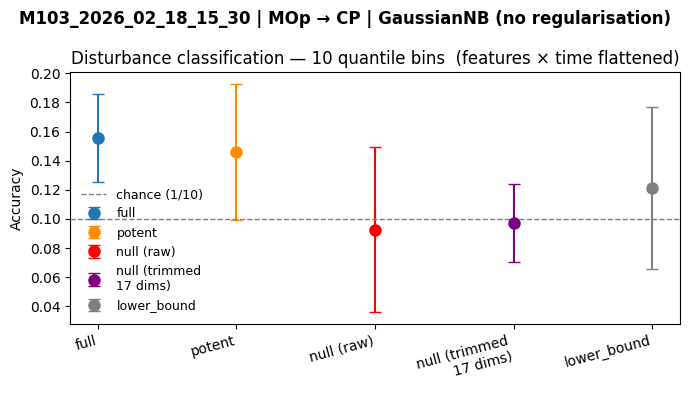

In [141]:
# ── Disturbance decoding as classification (GaussianNB) — no regularisation ───
# Bin disturb_sum into N quantile-based bins to get balanced classes.
# Arrays are flattened (features × time) — same approach as direction decoding.
# Uses the same subspaces and trimming as the cell above (_n_keep, _window_dist).

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold

_N_BINS = 10  # ← number of quantile bins (tertiles by default)

# ── bin disturb_sum into quantile-based labels ────────────────────────────────
_y_dist_binned = pd.qcut(_y_dist, q=_N_BINS, labels=False)
_chance = 1 / _N_BINS

_bins_categorical = pd.qcut(_y_dist, q=_N_BINS)
print(f'Bin edges: {_bins_categorical.categories.values}')
print(f'Class counts: {np.bincount(_y_dist_binned)}')
print(f'Chance level: {_chance:.3f}')

# ── build arrays (flattened: n_trials × (time * dims)) ───────────────────────
def _flatten(arr): return arr.reshape(arr.shape[0], -1)

_full_dist_f    = _flatten(np.stack(_td[_full_col].values)[:,   _window_dist[0]:_window_dist[1], :origin_rank])
_potent_dist_f  = _flatten(np.stack(_td[_potent_col].values)[:, _window_dist[0]:_window_dist[1], :])
_null_dist_r_f  = _flatten(np.stack(_td[_null_col].values)[:,   _window_dist[0]:_window_dist[1], :])
_null_dist_t_f  = _flatten(np.stack(_td[_null_col].values)[:,   _window_dist[0]:_window_dist[1], :_n_keep])

print(f'\nArray shapes — full: {_full_dist_f.shape}  potent: {_potent_dist_f.shape}  '
      f'null raw: {_null_dist_r_f.shape}  null trimmed: {_null_dist_t_f.shape}')

_rng2     = np.random.default_rng(seed=99)
_perm_bin = _rng2.permutation(len(_y_dist_binned))

# ── decode ────────────────────────────────────────────────────────────────────
_cv_cls = StratifiedKFold(5, shuffle=True)

def _cls(X, y, cv=_cv_cls):
    return cross_val_score(GaussianNB(), X, y, scoring='accuracy', cv=cv)

_acc_full    = _cls(_full_dist_f,   _y_dist_binned)
_acc_potent  = _cls(_potent_dist_f, _y_dist_binned)
_acc_null_r  = _cls(_null_dist_r_f, _y_dist_binned)
_acc_null_t  = _cls(_null_dist_t_f, _y_dist_binned)
_acc_lb      = _cls(_potent_dist_f, _y_dist_binned[_perm_bin])

print(f'\nDisturbance classification ({_N_BINS} bins):')
print(f'  Full:           {_acc_full.mean():.3f} ± {_acc_full.std():.3f}')
print(f'  Potent:         {_acc_potent.mean():.3f} ± {_acc_potent.std():.3f}')
print(f'  Null (raw):     {_acc_null_r.mean():.3f} ± {_acc_null_r.std():.3f}')
print(f'  Null (trimmed): {_acc_null_t.mean():.3f} ± {_acc_null_t.std():.3f}')
print(f'  Lower bound:    {_acc_lb.mean():.3f} ± {_acc_lb.std():.3f}')

# ── plot ──────────────────────────────────────────────────────────────────────
labels = ['full', 'potent', 'null (raw)', f'null (trimmed\n{_n_keep} dims)', 'lower_bound']
clrs   = ['tab:blue', 'darkorange', 'red', 'purple', 'gray']
scores = [_acc_full, _acc_potent, _acc_null_r, _acc_null_t, _acc_lb]

fig, ax = plt.subplots(figsize=(7, 4))
for i, (lbl, r2s, c) in enumerate(zip(labels, scores, clrs)):
    ax.errorbar(i, r2s.mean(), yerr=r2s.std(), color=c, fmt='o',
                markersize=8, capsize=4, label=lbl)
ax.axhline(_chance, color='gray', ls='--', lw=1, label=f'chance (1/{_N_BINS})')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title(f'Disturbance classification — {_N_BINS} quantile bins  (features × time flattened)')
ax.legend(frameon=False, fontsize=9)
plt.suptitle(f'{SESSIONS[0]} | {area_x} → {area_y} | GaussianNB (no regularisation)',
             fontweight='bold')
plt.tight_layout()
plt.show()


# M2 control

In [91]:
SESSIONS = [
    # "M061_2025_03_04_10_00",
    # "M061_2025_03_05_14_00",
    # "M061_2025_03_06_14_00",
    # "M063_2025_03_13_14_00",
    # "M063_2025_03_14_15_30",
    # "M062_2025_03_20_14_00",
    # "M062_2025_03_21_14_00",
    # "M078_2025_08_06_15_00",
    # "M086_2025_12_10_15_00",
    # "M103_2026_02_18_15_30",
    "M103_2026_02_20_16_00",
    # "M106_2026_02_25_15_00",
    # "M106_2026_02_26_16_00",
]


In [92]:
df_tr, dstrb_idx = dsp.load_and_process_session(SESSIONS[0], std=0.03)
perturb_td = pyal.restrict_to_interval(
    df_tr,
    start_point_name="idx_sol_on",
    rel_start=-200,
    rel_end=300,
)
perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)


fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
['all_spikes', 'MOp_spikes', 'CP_spikes', 'SSp_spikes', 'VAL_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.90029910269193% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.90029910269193% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.90029910269193% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.90029910269193% of trials
  warnings.warn(


Resulting all_spikes ephys data shape is (NxT): (18, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (65, 48000)
Resulting CP_spikes ephys data shape is (NxT): (136, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (43, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (164, 48000)


In [33]:
for area in Params.areas + ['GPe']:
    pr = dim.pca_pr(np.concatenate(perturb_td[f'{area}_rates'].values))
    print(f'{area}: {pr}')

MOp: 43.28902406513465
SSp: 10.664128624510449
CP: 56.77766975968756
VAL: 97.61325236903839
GPe: 28.221976066312813


In [123]:
area_x = 'MOp'
area_y = 'CP'
origin_rank=30
window=(200, 450)

td_potent_null = subspaces.compute_potent_null_td(
    td_=perturb_td_shuff,
    signal_x=f'{area_x}_rates_pca',
    signal_y=f'{area_y}_rates_pca',
    origin_rank=origin_rank,
    target_rank=30,
    n_iter=1,
    # window=window
)

Computing MOp_rates_pca -> CP_rates_pca potent and null subspaces
Prediction R2 = 0.2841. Optimal rank: 10
Using 1 iterations...
	Iter: 1. Prediction R2 = 0.0530
	Final Prediction R2 = 0.0060
Diagnostics:
	Total MOp_rates_pca var:         12480.15
	Fraction Potent (dim: 10) var:    0.210
	Fraction Null (dim: 10) var:      0.195
	Fraction Null init var:          0.415
	Fraction MOp_rates_pca var:      0.625


In [204]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, KFold

shuffle=True
alpha=0.01
window = (200, 400)

td_potent_null_dropped = dsp.drop_trials_sem_crosses_zero(td_potent_null, std=True)


td_potent_null_ord = (
    td_potent_null_dropped
    .sort_values(by='trial_id')
    .reset_index(drop=True)
)



full_arr = np.stack(td_potent_null_ord[f'{area_x}_rates_pca'].values)[:, window[0]:window[1], :origin_rank]
full_arr = full_arr.mean(1)

potent_arr = np.stack(td_potent_null_ord[f'{area_x}_rates_pca_potent_{area_y}_rates_pca'].values)[:, window[0]:window[1], :]
potent_arr = potent_arr.mean(1)

null_arr = np.stack(td_potent_null_ord[f'{area_x}_rates_pca_null_{area_y}_rates_pca'].values)[:, window[0]:window[1], :]
null_arr = null_arr.mean(1)

rng = np.random.default_rng(seed=42)
perm = rng.permutation(td_potent_null_ord.disturb_sum.values.shape[0])

# Disturbance decoding
y_dist = td_potent_null_ord.disturb_sum.values
r2s_full    = cross_val_score(Ridge(alpha), full_arr,   y_dist,       scoring=decode.get_custom_scorer(), cv=KFold(5, shuffle=shuffle))
r2s_potent  = cross_val_score(Ridge(alpha), potent_arr, y_dist,       scoring=decode.get_custom_scorer(), cv=KFold(5, shuffle=shuffle))
r2s_null    = cross_val_score(Ridge(alpha), null_arr,   y_dist,       scoring=decode.get_custom_scorer(), cv=KFold(5, shuffle=shuffle))
r2s_lower_bound = cross_val_score(Ridge(alpha), potent_arr, y_dist[perm], scoring=decode.get_custom_scorer(), cv=KFold(5, shuffle=shuffle))

print(f'Disturbance — full: {r2s_full.mean():.4f}  potent: {r2s_potent.mean():.4f}  null: {r2s_null.mean():.4f}  lb: {r2s_lower_bound.mean():.4f}')


window = (200, 300)

full_arr = np.stack(td_potent_null_ord[f'{area_x}_rates_pca'].values)[:, window[0]:window[1], :]
full_arr = full_arr.reshape(full_arr.shape[0], -1)

potent_arr = np.stack(td_potent_null_ord[f'{area_x}_rates_pca_potent_{area_y}_rates_pca'].values)[:, window[0]:window[1], :]
potent_arr = potent_arr.reshape(potent_arr.shape[0], -1)

null_arr = np.stack(td_potent_null_ord[f'{area_x}_rates_pca_null_{area_y}_rates_pca'].values)[:, window[0]:window[1], :]
null_arr = null_arr.reshape(null_arr.shape[0], -1)

rng = np.random.default_rng(seed=42)
perm = rng.permutation(td_potent_null_ord.disturb_sum.values.shape[0])
# Direction decoding
y_dir = np.array(td_potent_null_ord.values_Sol_direction.values.tolist())

perm_dir = rng.permutation(y_dir.shape[0])
r2s_full_dir    = cross_val_score(GaussianNB(), full_arr,   y_dir,           scoring='accuracy', cv=StratifiedKFold(4, shuffle=shuffle))
r2s_potent_dir  = cross_val_score(GaussianNB(), potent_arr, y_dir,           scoring='accuracy', cv=StratifiedKFold(4, shuffle=shuffle))
r2s_null_dir    = cross_val_score(GaussianNB(), null_arr,   y_dir,           scoring='accuracy', cv=StratifiedKFold(4, shuffle=shuffle))
r2s_lower_bound_dir = cross_val_score(GaussianNB(), potent_arr, y_dir[perm_dir], scoring='' \
'accuracy', cv=StratifiedKFold(4, shuffle=shuffle))

print(f'Direction     — full: {r2s_full_dir.mean():.4f}  potent: {r2s_potent_dir.mean():.4f}  null: {r2s_null_dir.mean():.4f}  lb: {r2s_lower_bound_dir.mean():.4f}')

  drop_trials_sem_crosses_zero: by SEM: 207  |  by value: 423  |  kept: 206/424 (48.6%)
Disturbance — full: 0.3144  potent: 0.3314  null: 0.1330  lb: 0.0158
Direction     — full: 0.3202  potent: 0.3304  null: 0.2720  lb: 0.0873


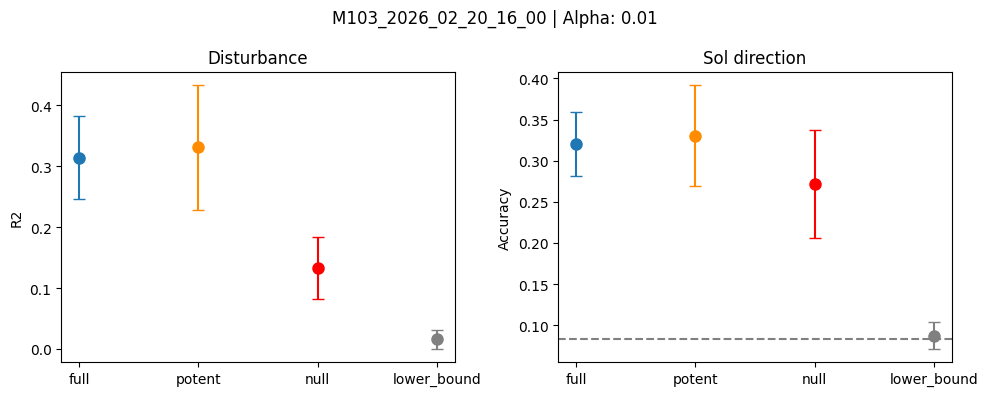

In [205]:
labels = ['full', 'potent', 'null', 'lower_bound']
clrs   = ['tab:blue', 'darkorange', 'red', 'gray']

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

data = [
    (axs[0], 'Disturbance', [r2s_full, r2s_potent, r2s_null, r2s_lower_bound], 'R2', ),
    (axs[1], 'Sol direction', [r2s_full_dir, r2s_potent_dir, r2s_null_dir, r2s_lower_bound_dir], 'Accuracy'),
]

for ax, title, r2s_list, ylabel in data:
    for i, (lbl, r2s, c) in enumerate(zip(labels, r2s_list, clrs)):
        ax.errorbar(i, r2s.mean(), yerr=r2s.std(), color=c, fmt='o', markersize=8, capsize=4, label=lbl)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if ylabel=='Accuracy':
        ax.axhline(1/12, color='gray', linestyle='dashed')
plt.suptitle(f'{SESSIONS[0]} | Alpha: {alpha}')
plt.tight_layout()

# Muscimol sessions

In [ ]:
SESSIONS = [
    # "M061_2025_03_04_10_00",
    # "M061_2025_03_05_14_00",
    # "M061_2025_03_06_14_00",
    # "M063_2025_03_13_14_00",
    # "M063_2025_03_14_15_30",
    # "M062_2025_03_20_14_00",
    # "M062_2025_03_21_14_00",
    # "M078_2025_08_06_15_00",
    # "M086_2025_12_10_15_00",
    # "M103_2026_02_18_15_30",
    # "M103_2026_02_20_16_00",
    # "M106_2026_02_25_15_00",
    # "M106_2026_02_26_16_00",
]


In [4]:
df_tr, dstrb_idx = dsp.load_and_process_session(SESSIONS[0], std=0.03)
perturb_td = pyal.restrict_to_interval(
    df_tr,
    start_point_name="idx_sol_on",
    rel_start=-200,
    rel_end=300,
)
perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)


fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
['CP_spikes', 'all_spikes', 'MOp_spikes', 'SSp_spikes', 'VAL_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.90029910269193% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.90029910269193% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.90029910269193% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.90029910269193% of trials
  warnings.warn(


Resulting CP_spikes ephys data shape is (NxT): (136, 48000)
Resulting all_spikes ephys data shape is (NxT): (18, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (65, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (43, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (164, 48000)
Skipped 36 trials
Otsu immobility threshold: 1.8090
Dropped 17 of 500 rows (3.40%).


In [221]:
perturb_td.head()

,animal,session,trial_id,trial_name,trial_length,bin_size,idx_trial_start,idx_trial_end,idx_CPI,values_before_camera_trigger,...,VAL_rates_pca,bhv,bhv_concat,concat_perturb_time,concat_trial_start,power,phases,disturb_score,disturb_mean,disturb_sum
0,M103,M103_2026_02_20_16_00,4,trial,600,0.01,NaN,NaN,[],[],...,"[[151.23987, 29.7471, -102.46189, -19.912413, ...","[[3.567505504220974, 12.02239550555921, 196.13...","[[191.4182486804028, 173.1837211494131, 186.47...",700,500,"[[0.3912402530322886, 0.3548856344194174, -0.1...","[[1.542307865592019, 1.6607689832002783, 1.532...","[-0.8626675160450595, -0.9578687394243778, -0....",-0.941486,1.052995
1,M103,M103_2026_02_20_16_00,10,trial,600,0.01,NaN,NaN,[],[],...,"[[187.18527, -16.758606, -106.95794, 8.55644, ...","[[13.958921636329125, 14.279778750846695, 183....","[[188.4985077496947, 171.57179451476225, 182.2...",700,500,"[[0.8121951708344048, 0.0985686615137322, 0.67...","[[-1.1372070808223695, -1.514950665083925, 1.4...","[1.2592147656835257, 1.6926506734433313, 1.334...",1.537885,1.266105
2,M103,M103_2026_02_20_16_00,16,trial,600,0.01,NaN,NaN,[],[],...,"[[196.9878, 39.628143, -65.82507, 54.302116, 1...","[[13.12203741016982, 12.980142857537423, 185.8...","[[184.1742683374992, 173.98274254878947, 178.6...",300,100,"[[1.3431689546650554, 0.5151547321833212, 1.74...","[[-2.3722722996623458, 1.494702906253605, -1.8...","[-0.3396136537794447, -0.36065316198610026, -0...",-0.252509,0.481458
3,M103,M103_2026_02_20_16_00,20,trial,600,0.01,NaN,NaN,[],[],...,"[[175.5808, -67.34172, -81.0436, 16.14712, 4.3...","[[18.057392208313058, 14.970131053310666, 181....","[[187.6250679324896, 171.10055332835316, 184.9...",500,300,"[[0.818288538628744, 1.4646970531608168, -0.94...","[[0.9130781810137332, -2.7113421125575843, 1.3...","[-1.5066889131310988, -2.2436401041275458, -0....",-1.742184,1.320275
4,M103,M103_2026_02_20_16_00,22,trial,600,0.01,NaN,NaN,[],[],...,"[[44.24845, 37.231567, 105.71675, 54.194298, -...","[[18.638491616467554, 12.5444030917478, 188.83...","[[180.09814052573287, 164.25195633587305, 173....",700,500,"[[1.2878350220429784, 1.3146417377990083, 1.53...","[[-1.5629380861002078, 1.6127950097884545, -1....","[2.7397899046033904, 1.2852292183263878, 2.313...",2.234142,1.428292


In [223]:
pc_dict = {}
for area in Params.areas:
    pr = dim.pca_pr(np.concatenate(all_sess['M103_2026_02_18_15_30']['td'][f'{area}_rates'].values))
    pc_dict[area] = int(pr)
    print(f'{area}: {int(pr)}')

MOp: 21
SSp: 33
CP: 27
VAL: 12


In [224]:
pc_dict = {}
for area in Params.areas:
    pr = dim.pca_pr(np.concatenate(all_sess['M103_2026_02_20_16_00']['td'][f'{area}_rates'].values))
    pc_dict[area] = int(pr)
    print(f'{area}: {int(pr)}')

MOp: 2
SSp: 2
CP: 19
VAL: 20


  drop_trials_sem_crosses_zero: by SEM: 207  |  by value: 423  |  kept: 206/424 (48.6%)
MOp  R2: 0.3457  lb: 0.0138
SSp  R2: 0.3119  lb: 0.0365
CP  R2: 0.2159  lb: 0.0283
VAL  R2: 0.2201  lb: 0.0200
MOp  acc: 0.3742  lb: 0.0824
SSp  acc: 0.2524  lb: 0.1163
CP  acc: 0.2673  lb: 0.1213
VAL  acc: 0.3251  lb: 0.1167


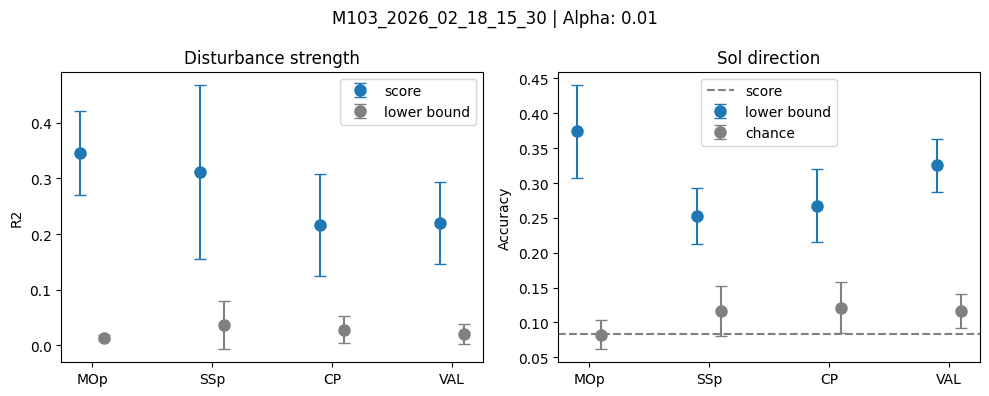

In [138]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Ridge
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score

shuffle = True
alpha = 0.01
dist_window = (200, 400)
dir_window  = (200, 300)
origin_rank = 30
td_dropped = dsp.drop_trials_sem_crosses_zero(perturb_td_shuff, std=True)

td_ord = (
    td_dropped
    .sort_values(by='trial_id')
    .reset_index(drop=True)
)
pc_dict = {
    "MOp": 30,
    "SSp": 43,
    "CP": 45,
    "VAL": 50,
}

y_dist = td_ord.disturb_sum.values
y_dir  = np.array(td_ord.values_Sol_direction.values.tolist())

rng       = np.random.default_rng(seed=42)
perm_dist = rng.permutation(len(y_dist))
perm_dir  = rng.permutation(len(y_dir))

areas        = Params.areas
results_dist = {}
results_dir  = {}

for area in areas:
    arr = np.stack(td_ord[f"{area}_rates_pca"].values)

    dist_arr = arr[:, dist_window[0]:dist_window[1], :pc_dict[area]].mean(1)
    results_dist[area] = {
        "score": cross_val_score(Ridge(alpha), dist_arr, y_dist,            scoring=decode.get_custom_scorer(), cv=KFold(5, shuffle=shuffle)),
        "lb":    cross_val_score(Ridge(alpha), dist_arr, y_dist[perm_dist],  scoring=decode.get_custom_scorer(), cv=KFold(5, shuffle=shuffle)),
    }

    dir_arr = arr[:, dir_window[0]:dir_window[1], :pc_dict[area]].reshape(arr.shape[0], -1)
    results_dir[area] = {
        "score": cross_val_score(GaussianNB(), dir_arr, y_dir,           scoring="accuracy", cv=StratifiedKFold(4, shuffle=shuffle)),
        "lb":    cross_val_score(GaussianNB(), dir_arr, y_dir[perm_dir],  scoring="accuracy", cv=StratifiedKFold(4, shuffle=shuffle)),
    }

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
x = np.arange(len(areas))

ax = axs[0]
for i, area in enumerate(areas):
    s, lb = results_dist[area]["score"], results_dist[area]["lb"]
    ax.errorbar(i - 0.1, s.mean(),  yerr=s.std(),  fmt="o", color="tab:blue", capsize=4, markersize=8)
    ax.errorbar(i + 0.1, lb.mean(), yerr=lb.std(), fmt="o", color="gray",     capsize=4, markersize=8)
    print(f"{area}  R2: {s.mean():.4f}  lb: {lb.mean():.4f}")
ax.set_xticks(x)
ax.set_xticklabels(areas)
ax.set_ylabel("R2")
ax.set_title("Disturbance strength")
ax.legend(["score", "lower bound"], loc="best")

ax = axs[1]
for i, area in enumerate(areas):
    s, lb = results_dir[area]["score"], results_dir[area]["lb"]
    ax.errorbar(i - 0.1, s.mean(),  yerr=s.std(),  fmt="o", color="tab:blue", capsize=4, markersize=8)
    ax.errorbar(i + 0.1, lb.mean(), yerr=lb.std(), fmt="o", color="gray",     capsize=4, markersize=8)
    print(f"{area}  acc: {s.mean():.4f}  lb: {lb.mean():.4f}")
ax.axhline(1/12, color="gray", linestyle="dashed")
ax.set_xticks(x)
ax.set_xticklabels(areas)
ax.set_ylabel("Accuracy")
ax.set_title("Sol direction")
ax.legend(["score", "lower bound", "chance"], loc="best")

plt.suptitle(f"{SESSIONS[0]} | Alpha: {alpha}")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Ridge
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score

alpha       = 0.01
dist_window = (200, 400)
dir_window  = (200, 300)
n_perms     = 100
pc_dict = {
    "MOp": 30,
    "SSp": 43,
    "CP": 45,
    "VAL": 50,
}

td_ord = perturb_td_shuff.sort_values(by="trial_id").reset_index(drop=True)

y_dist = td_ord.disturb_sum.values
y_dir  = np.array(td_ord.values_Sol_direction.values.tolist())

rng = np.random.default_rng(seed=42)

results_dist = {}
results_dir  = {}

for area in Params.areas:
    arr = np.stack(td_ord[f"{area}_rates_pca"].values)

    dist_arr = arr[:, dist_window[0]:dist_window[1], :pc_dict[area]].mean(1)
    r2s    = cross_val_score(Ridge(alpha), dist_arr, y_dist, scoring=decode.get_custom_scorer(),
                             cv=KFold(5, shuffle=True, random_state=42))
    r2s_lb = np.array([cross_val_score(Ridge(alpha), dist_arr, y_dist[rng.permutation(len(y_dist))],
                                       scoring=decode.get_custom_scorer(),
                                       cv=KFold(5, shuffle=True, random_state=42))
                       for _ in range(n_perms)]).mean(axis=0)
    results_dist[area] = {"score": r2s, "lb": r2s_lb}

    dir_arr = arr[:, dir_window[0]:dir_window[1], :].reshape(arr.shape[0], -1)
    acc    = cross_val_score(GaussianNB(), dir_arr, y_dir, scoring="accuracy",
                             cv=StratifiedKFold(4, shuffle=True, random_state=42))
    acc_lb = np.array([cross_val_score(GaussianNB(), dir_arr, y_dir[rng.permutation(len(y_dir))],
                                       scoring="accuracy",
                                       cv=StratifiedKFold(4, shuffle=True, random_state=42))
                       for _ in range(n_perms)]).mean(axis=0)
    results_dir[area] = {"score": acc, "lb": acc_lb}

    print(f"{area}  disturbance R2: {r2s.mean():.4f} (lb {r2s_lb.mean():.4f})   direction acc: {acc.mean():.4f} (lb {acc_lb.mean():.4f})")


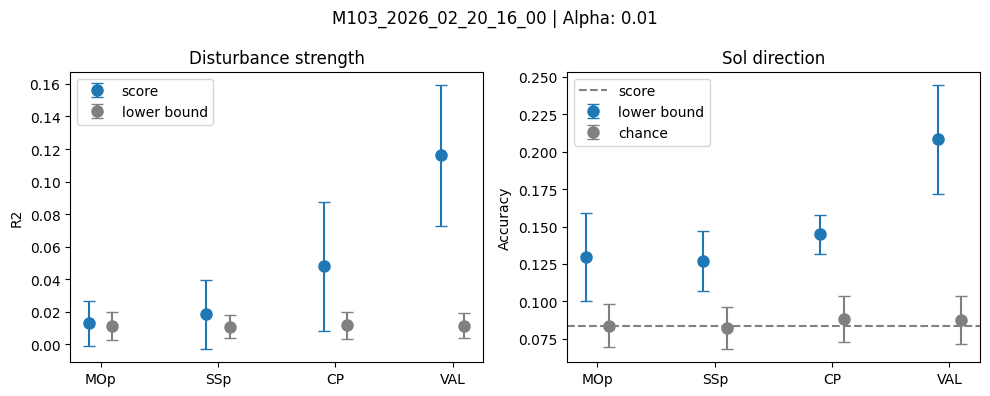

In [212]:
areas = Params.areas
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
x = np.arange(len(areas))

ax = axs[0]
for i, area in enumerate(areas):
    s, lb = results_dist[area]["score"], results_dist[area]["lb"]
    ax.errorbar(i - 0.1, s.mean(),  yerr=s.std(),  fmt="o", color="tab:blue", capsize=4, markersize=8)
    ax.errorbar(i + 0.1, lb.mean(), yerr=lb.std(), fmt="o", color="gray",     capsize=4, markersize=8)
ax.set_xticks(x)
ax.set_xticklabels(areas)
ax.set_ylabel("R2")
ax.set_title("Disturbance strength")
ax.legend(["score", "lower bound"], loc="best")

ax = axs[1]
for i, area in enumerate(areas):
    s, lb = results_dir[area]["score"], results_dir[area]["lb"]
    ax.errorbar(i - 0.1, s.mean(),  yerr=s.std(),  fmt="o", color="tab:blue", capsize=4, markersize=8)
    ax.errorbar(i + 0.1, lb.mean(), yerr=lb.std(), fmt="o", color="gray",     capsize=4, markersize=8)
ax.axhline(1/12, color="gray", linestyle="dashed")
ax.set_xticks(x)
ax.set_xticklabels(areas)
ax.set_ylabel("Accuracy")
ax.set_title("Sol direction")
ax.legend(["score", "lower bound", "chance"], loc="best")

plt.suptitle(f"{SESSIONS[0]} | Alpha: {alpha}")
plt.tight_layout()
plt.show()


## Comparison between sessions

In [250]:
SESSIONS = [
    # "M103_2026_02_18_15_30",
    # "M103_2026_02_20_16_00",
    "M106_2026_02_25_15_00",
    "M106_2026_02_27_16_00",
]
all_sess = dsp.load_sessions_for_trial_analyses(SESSIONS, std=0.05, std_dropping=True)

Loading sessions:   0%|          | 0/2 [00:00<?, ?it/s]


M106_2026_02_25_15_00


fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
['CP_spikes', 'MOp_spikes', 'all_spikes', 'VAL_spikes', 'SSp_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(


Resulting CP_spikes ephys data shape is (NxT): (206, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (156, 48000)
Resulting all_spikes ephys data shape is (NxT): (11, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (132, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (142, 48000)
add_concat_perturb_time: dropping 1 trial(s) with missing idx_sol_on
Skipped 87 trials
Otsu immobility threshold: 2.2123
Dropped 130 of 499 rows (26.05%).
Thresh val dropping -2
  drop_trials_sem_crosses_zero: by SEM: 167  |  by value: 309  |  kept: 151/325 (46.5%)


...


M106_2026_02_27_16_00
fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
['CP_spikes', 'MOp_spikes', 'all_spikes', 'SSp_spikes', 'VAL_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.89939637826963% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.89939637826963% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.89939637826963% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.89939637826963% of trials
  warnings.warn(


Resulting CP_spikes ephys data shape is (NxT): (118, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (49, 48000)
Resulting all_spikes ephys data shape is (NxT): (7, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (37, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (166, 48000)
add_concat_perturb_time: dropping 1 trial(s) with missing idx_sol_on
Skipped 21 trials
Otsu immobility threshold: 2.0868
Dropped 32 of 495 rows (6.46%).
Thresh val dropping -2
  drop_trials_sem_crosses_zero: by SEM: 224  |  by value: 427  |  kept: 197/454 (43.4%)


Loading sessions: 100%|██████████| 2/2 [01:32<00:00, 46.23s/it]


Loaded 2/2 sessions successfully.


In [9]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Ridge
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score

alpha       = 0.01
dist_window = (200, 400)
dir_window  = (200, 250)
n_perms     = 20
seed = 40

sess_results = {}  # {sess: {area: {dist: {score, lb}, dir: {score, lb}}}}
pc_dict = {
    "MOp": 25,
    "SSp": 20,
    "CP": 35,
    "VAL": 50,
}
for sess, val in all_sess.items():
    if val is None:
        continue
    td = val["td"].sort_values(by="trial_id").reset_index(drop=True)

    y_dist = td.disturb_sum.values
    y_dir  = np.array(td.values_Sol_direction.values.tolist())
    rng    = np.random.default_rng(seed=seed)
    _, counts = np.unique(y_dir, return_counts=True)
    chance = counts.max() / counts.sum()

    sess_results[sess] = {"chance": chance}
    for area in Params.areas:
        arr = np.stack(td[f"{area}_rates_pca"].values)

        dist_arr = arr[:, dist_window[0]:dist_window[1], :pc_dict[area]].mean(1)
        r2s    = cross_val_score(Ridge(alpha), dist_arr, y_dist, scoring=decode.get_custom_scorer(),
                                 cv=KFold(5, shuffle=True, random_state=seed))
        r2s_lb = np.array([cross_val_score(Ridge(alpha), dist_arr, y_dist[rng.permutation(len(y_dist))],
                                           scoring=decode.get_custom_scorer(),
                                           cv=KFold(5, shuffle=True, random_state=seed))
                           for _ in range(n_perms)]).mean(axis=0)

        dir_arr = arr[:, dir_window[0]:dir_window[1], :].reshape(arr.shape[0], -1)
        acc    = cross_val_score(GaussianNB(), dir_arr, y_dir, scoring="accuracy",
                                 cv=StratifiedKFold(5, shuffle=True, random_state=seed))
        acc_lb = np.array([cross_val_score(GaussianNB(), dir_arr, y_dir[rng.permutation(len(y_dir))],
                                           scoring="accuracy",
                                           cv=StratifiedKFold(5, shuffle=True, random_state=seed))
                           for _ in range(n_perms)]).mean(axis=0)

        sess_results[sess][area] = {
            "dist": {"score": r2s,  "lb": r2s_lb},
            "dir":  {"score": acc,  "lb": acc_lb},
        }
        print(f"{sess} | {area}  R2: {r2s.mean():.4f} (lb {r2s_lb.mean():.4f})   acc: {acc.mean():.4f} (lb {acc_lb.mean():.4f})")


M103_2026_02_18_15_30 | MOp  R2: 0.3482 (lb 0.0137)   acc: 0.4467 (lb 0.1096)
M103_2026_02_18_15_30 | SSp  R2: 0.2332 (lb 0.0214)   acc: 0.2854 (lb 0.1053)
M103_2026_02_18_15_30 | CP  R2: 0.2952 (lb 0.0186)   acc: 0.3025 (lb 0.1079)
M103_2026_02_18_15_30 | VAL  R2: 0.1103 (lb 0.0195)   acc: 0.2508 (lb 0.1052)
M103_2026_02_20_16_00 | MOp  R2: 0.0390 (lb 0.0163)   acc: 0.1023 (lb 0.0887)
M103_2026_02_20_16_00 | SSp  R2: 0.0401 (lb 0.0192)   acc: 0.0639 (lb 0.0920)
M103_2026_02_20_16_00 | CP  R2: 0.0054 (lb 0.0137)   acc: 0.1535 (lb 0.1109)
M103_2026_02_20_16_00 | VAL  R2: 0.0598 (lb 0.0175)   acc: 0.2652 (lb 0.1007)
M106_2026_02_25_15_00 | MOp  R2: 0.3262 (lb 0.0162)   acc: 0.3105 (lb 0.1319)
M106_2026_02_25_15_00 | SSp  R2: 0.2736 (lb 0.0211)   acc: 0.2037 (lb 0.1507)
M106_2026_02_25_15_00 | CP  R2: 0.2813 (lb 0.0219)   acc: 0.2224 (lb 0.1516)
M106_2026_02_25_15_00 | VAL  R2: 0.2695 (lb 0.0233)   acc: 0.2268 (lb 0.1426)
M106_2026_02_27_16_00 | MOp  R2: 0.0947 (lb 0.0152)   acc: 0.1472 (

MOp  dist  s1:0.4953 lb1:0.0356  s2:0.0457 lb2:0.0268
SSp  dist  s1:0.3752 lb1:0.0319  s2:0.0545 lb2:0.0269
CP  dist  s1:0.4384 lb1:0.0299  s2:0.1974 lb2:0.0306
VAL  dist  s1:0.4196 lb1:0.0252  s2:0.4578 lb2:0.0221
MOp  dir  s1:0.2578 lb1:0.1370  s2:0.1621 lb2:0.1046
SSp  dir  s1:0.2252 lb1:0.1500  s2:0.1976 lb2:0.1010
CP  dir  s1:0.2383 lb1:0.1494  s2:0.2082 lb2:0.1273
VAL  dir  s1:0.1918 lb1:0.1550  s2:0.4364 lb2:0.1248


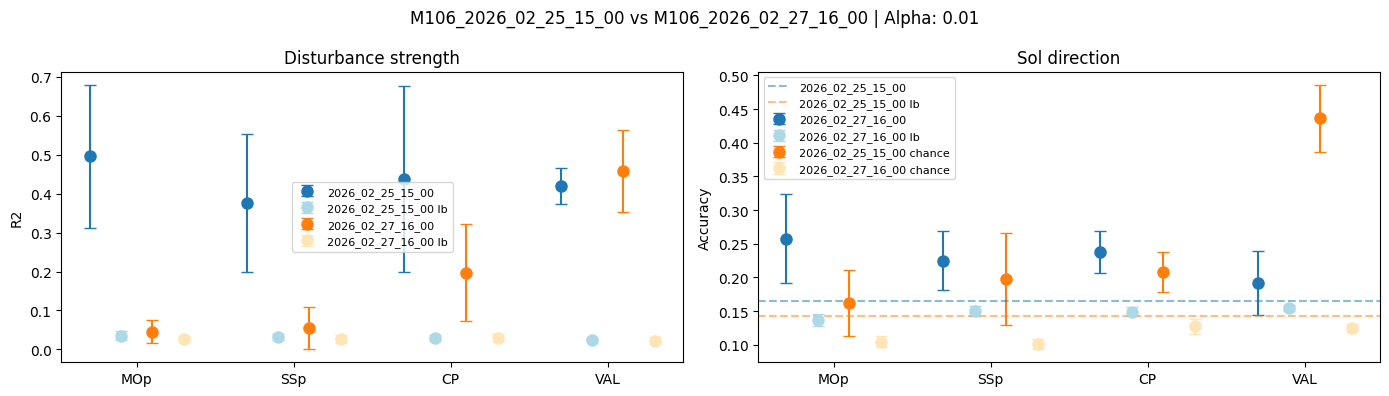

In [257]:
sessions = [s for s in all_sess if all_sess[s] is not None]
areas    = Params.areas
sess1, sess2 = sessions[0], sessions[1]

fig, axs = plt.subplots(1, 2, figsize=(14, 4))

col_colors = ["tab:blue", "lightblue", "tab:orange", "moccasin"]
col_labels = [f"{sess1[-16:]}", f"{sess1[-16:]} lb", f"{sess2[-16:]}", f"{sess2[-16:]} lb"]

for ax, metric, ylabel in [
    (axs[0], "dist", "R2"),
    (axs[1], "dir",  "Accuracy"),
]:
    for a_idx, area in enumerate(areas):
        offsets = [-0.3, -0.1, 0.1, 0.3]
        s1  = sess_results[sess1][area][metric]["score"]
        lb1 = sess_results[sess1][area][metric]["lb"]
        s2  = sess_results[sess2][area][metric]["score"]
        lb2 = sess_results[sess2][area][metric]["lb"]
        for val, off, clr in zip([s1, lb1, s2, lb2], offsets, col_colors):
            ax.errorbar(a_idx + off, val.mean(), yerr=val.std(), fmt="o", color=clr, capsize=4, markersize=8)
        print(f"{area}  {metric}  s1:{s1.mean():.4f} lb1:{lb1.mean():.4f}  s2:{s2.mean():.4f} lb2:{lb2.mean():.4f}")

    if metric == "dir":
        ax.axhline(sess_results[sess1]["chance"], color="tab:blue",   linestyle="dashed", alpha=0.5, label=f"{sess1[-16:]} chance")
        ax.axhline(sess_results[sess2]["chance"], color="tab:orange", linestyle="dashed", alpha=0.5, label=f"{sess2[-16:]} chance")
    ax.set_xticks(range(len(areas)))
    ax.set_xticklabels(areas)
    ax.set_ylabel(ylabel)
    ax.set_title("Disturbance strength" if metric == "dist" else "Sol direction")

axs[0].legend(col_labels, loc="best", fontsize=8)
axs[1].legend(col_labels + [f"{sess1[-16:]} chance", f"{sess2[-16:]} chance"], loc="best", fontsize=8)

plt.suptitle(f"{sess1} vs {sess2} | Alpha: {alpha}")
plt.tight_layout()
plt.show()


In [259]:
def decode_direction_by_area(td, areas, window=20, step=2, k=5, shuffle=False, rnd=None):
    """
    Run moving-window direction decoding (values_Sol_direction) for each area.

    Parameters
    ----------
    td     : pd.DataFrame  trial table restricted to the epoch of interest
    areas  : list[str]     area names (resolved to '{area}_rates_pca') or raw
                           column names (e.g. 'bhv') used directly if the
                           '_rates_pca' variant is absent
    window : int           sliding window length in bins
    step   : int           step size in bins
    k      : int           number of CV folds (StratifiedKFold)

    Returns
    -------
    results : dict  {area: {'scores': ndarray (folds × time), 'times': ndarray}}
    """
    y = np.array(td.values_Sol_direction.values.tolist(), dtype=int)
    cv = StratifiedKFold(n_splits=k, shuffle=shuffle, random_state=rnd)
    results = {}
    for area in areas:
        pca_label = f"{area}_rates_pca"
        if pca_label in td.columns:
            label = pca_label
        elif area in td.columns:
            label = area
        else:
            print(f"  {area}: no column '{pca_label}' or '{area}' found, skipping")
            continue
        X = np.stack(td[label].values)
        scores, times = decode.moving_window_decoding(
            X, y, cv=cv, window_length_bin=window, step_bin=step
        )
        results[area] = {"scores": scores, "times": times}
        print(f"  {area}: done  (mean acc = {np.mean(scores):.3f})")
    return results

def plot_decoding_by_area(results, areas, chance=None, peak_lags=None):
    """Plot mean ± SEM decoding curves (left) and per-fold CoM summary (right)."""
    show_com = peak_lags is not None and any(
        "com_folds" in peak_lags.get(a, {}) for a in areas
    )
    if show_com:
        fig, (ax, ax_com) = plt.subplots(
            1, 2, figsize=(10, 8), gridspec_kw={"width_ratios": [3, 1]}
        )
    else:
        fig, ax = plt.subplots(figsize=(8, 6))
        ax_com = None

    for area in areas:
        if area not in results:
            continue
        scores = results[area]["scores"]
        times  = results[area]["times"]
        color = getattr(colors, f'{area}_light', None)
        vizutils.shaded_errorbar(ax, times - 2, scores, color=color, label=area)

    if chance is not None:
        ax.axhline(chance, color="k", linestyle="dashed", label="chance")
    ax.axvline(0, color="gray", linestyle="dashed", label="perturb")

    # peak-lag dots at the top
    if peak_lags is not None:
        y_top = ax.get_ylim()[1]
        dot_y = y_top * 0.97
        for area in areas:
            if area not in peak_lags:
                continue
            color = getattr(colors, f'{area}_light')
            ax.scatter(peak_lags[area]["peak"], dot_y, color=color,
                       s=80, zorder=5, clip_on=False)

    ax.set_xlabel("Time rel. perturb. (s)")
    ax.set_ylabel("Decoding Accuracy (%)")
    ax.set_title("Direction decoding by area")
    ax.legend(frameon=False)

    # CoM subplot
    if show_com and ax_com is not None:
        present = [a for a in areas if a in peak_lags and "com_folds" in peak_lags[a]]
        x_pos = np.arange(len(present))
        for i, area in enumerate(present):
            c = getattr(colors, area, "steelblue")
            mean  = peak_lags[area]["com_mean"]
            std   = peak_lags[area]["com_std"]
            folds = peak_lags[area]["com_folds"]
            ax_com.scatter(np.full_like(folds, i, dtype=float), folds,
                           color=c, alpha=0.4, s=25, zorder=3)
            ax_com.errorbar(i, mean, yerr=std, fmt="o", color=c,
                            capsize=4, capthick=1.5, ms=7, zorder=4)
        ax_com.axhline(0, color="gray", linestyle=":", lw=0.8)
        ax_com.set_xticks(x_pos)
        ax_com.set_xticklabels(present, rotation=45, ha="right")
        ax_com.set_ylabel("CoM lag (s)")
        ax_com.set_title("CoM per fold")

    plt.tight_layout()
    return fig, ax



In [261]:
results_s = decode_direction_by_area(all_sess[sess1]['td'], Params.areas, step=2, k=4, shuffle=True, rnd=40)

100%|██████████| 482/482 [00:16<00:00, 29.79it/s]


  MOp: done  (mean acc = 0.145)


100%|██████████| 482/482 [00:14<00:00, 33.47it/s]


  SSp: done  (mean acc = 0.149)


100%|██████████| 482/482 [00:16<00:00, 29.03it/s]


  CP: done  (mean acc = 0.150)


100%|██████████| 482/482 [00:13<00:00, 34.59it/s]

  VAL: done  (mean acc = 0.155)


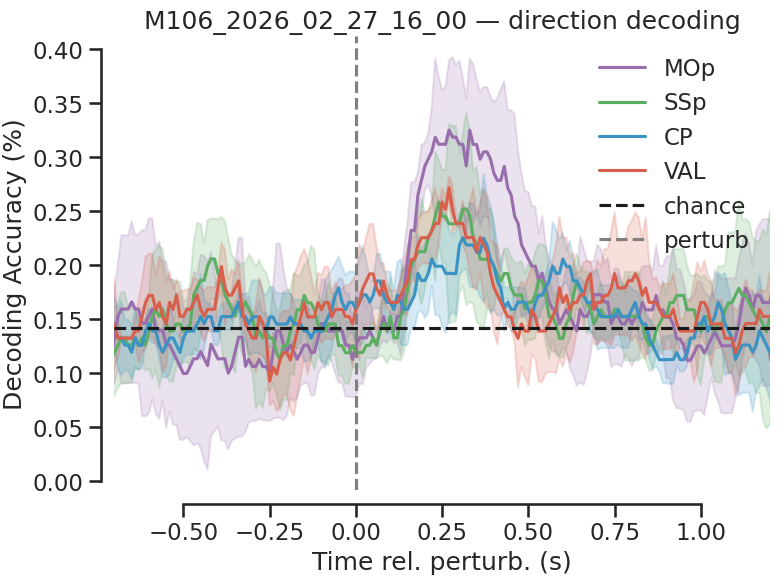

In [264]:
with vizutils.apply_plot_style():
    fig, ax = plot_decoding_by_area(results_s, Params.areas, chance=sess_results[sess]["chance"])
    ax.set_xlim(-0.7, 1.2)
    ax.set_title(f"{sess} — direction decoding")
plt.show()

In [265]:
results_s = decode_direction_by_area(all_sess[sess2]['td'], Params.areas, step=2, k=4, shuffle=True, rnd=40)

100%|██████████| 241/241 [00:04<00:00, 56.04it/s]


  MOp: done  (mean acc = 0.106)


100%|██████████| 241/241 [00:04<00:00, 58.27it/s]


  SSp: done  (mean acc = 0.111)


100%|██████████| 241/241 [00:06<00:00, 35.19it/s]


  CP: done  (mean acc = 0.138)


100%|██████████| 241/241 [00:07<00:00, 30.59it/s]


  VAL: done  (mean acc = 0.161)


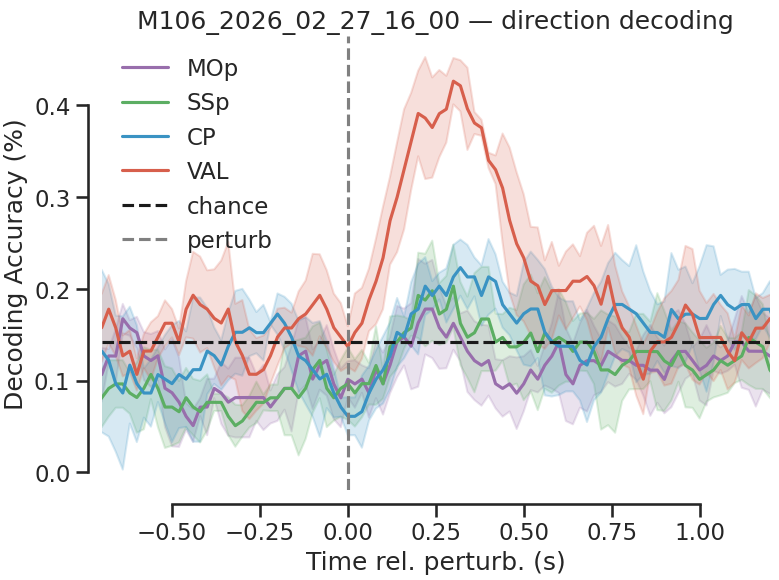

In [266]:
with vizutils.apply_plot_style():
    fig, ax = plot_decoding_by_area(results_s, Params.areas, chance=sess_results[sess]["chance"])
    ax.set_xlim(-0.7, 1.2)
    ax.set_title(f"{sess} — direction decoding")
plt.show()

## Comparison 4 sessions

In [3]:
SESSIONS = [
    "M103_2026_02_18_15_30",
    "M103_2026_02_20_16_00",
    "M106_2026_02_25_15_00",
    "M106_2026_02_27_16_00",
]
all_sess = dsp.load_sessions_for_trial_analyses(SESSIONS, std=0.03, std_dropping=False)

Loading sessions:   0%|          | 0/4 [00:00<?, ?it/s]


M103_2026_02_18_15_30


fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
['all_spikes', 'CP_spikes', 'MOp_spikes', 'VAL_spikes', 'SSp_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(


Resulting all_spikes ephys data shape is (NxT): (15, 48000)
Resulting CP_spikes ephys data shape is (NxT): (267, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (190, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (126, 48000)
Skipped 8 trials
Otsu immobility threshold: 6.6387
Dropped 70 of 497 rows (14.08%).
Thresh val dropping -2
  drop_trials_sem_crosses_zero: by SEM: 293  |  by value: 424  |  kept: 292/425 (68.7%)


...


M106_2026_02_27_16_00
fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
['CP_spikes', 'MOp_spikes', 'all_spikes', 'SSp_spikes', 'VAL_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.89939637826963% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.89939637826963% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.89939637826963% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.89939637826963% of trials
  warnings.warn(


Resulting CP_spikes ephys data shape is (NxT): (118, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (49, 48000)
Resulting all_spikes ephys data shape is (NxT): (7, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (37, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (166, 48000)
add_concat_perturb_time: dropping 1 trial(s) with missing idx_sol_on
Skipped 21 trials
Otsu immobility threshold: 2.0868
Dropped 32 of 495 rows (6.46%).
Thresh val dropping -2
  drop_trials_sem_crosses_zero: by SEM: 322  |  by value: 444  |  kept: 312/454 (68.7%)


Loading sessions: 100%|██████████| 4/4 [02:05<00:00, 31.35s/it]


Loaded 4/4 sessions successfully.


In [269]:
for sess in SESSIONS:
    print(sess)
    pc_dict = {}
    for area in Params.areas:
        pr = dim.pca_pr(np.concatenate(all_sess[sess]['td'][f'{area}_rates'].values))
        pc_dict[area] = int(pr)
        print(f'{area}: {int(pr)}')

M103_2026_02_18_15_30
MOp: 21
SSp: 33
CP: 27
VAL: 12
M103_2026_02_20_16_00
MOp: 2
SSp: 2
CP: 19
VAL: 20
M106_2026_02_25_15_00
MOp: 19
SSp: 26
CP: 30
VAL: 28
M106_2026_02_27_16_00
MOp: 4
SSp: 2
CP: 30
VAL: 33


In [18]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Ridge
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score

alpha       = 0.1
dist_window = (200, 250)
dir_window  = (200, 250)
seed        = 42

sess_results_4 = {}  # {sess: {area: {dist: score, dir: score}, chance: float}}
pc_dict = {
    'MOp': 25,
    'SSp': 25,
    'CP': 30,
    'VAL': 35
}

for sess, val in all_sess.items():
    if val is None:
        continue
    td = val["td"].sort_values(by="trial_id").reset_index(drop=True)

    y_dist = td.disturb_sum.values
    y_dir  = np.array(td.values_Sol_direction.values.tolist())
    _, counts = np.unique(y_dir, return_counts=True)
    chance = counts.max() / counts.sum()

    sess_results_4[sess] = {"chance": chance}
    for area in Params.areas:
        arr = np.stack(td[f"{area}_rates_pca"].values)

        dist_arr = arr[:, dist_window[0]:dist_window[1], :pc_dict[area]].mean(1)
        r2s = cross_val_score(Ridge(alpha), dist_arr, y_dist, scoring=make_scorer(r2_score),
                              cv=KFold(5, shuffle=True, random_state=seed))

        dir_arr = arr[:, dir_window[0]:dir_window[1], :].reshape(len(y_dir), -1)
        acc = cross_val_score(GaussianNB(), dir_arr, y_dir, scoring="accuracy",
                              cv=StratifiedKFold(5, shuffle=True, random_state=seed))

        sess_results_4[sess][area] = {
            "dist": r2s,
            "dir":  acc,
        }
        print(f"{sess} | {area}  R2: {r2s.mean():.4f}   acc: {acc.mean():.4f}")


M103_2026_02_18_15_30 | MOp  R2: 0.4543   acc: 0.4225
M103_2026_02_18_15_30 | SSp  R2: 0.3927   acc: 0.2819
M103_2026_02_18_15_30 | CP  R2: 0.2391   acc: 0.2819
M103_2026_02_18_15_30 | VAL  R2: 0.2220   acc: 0.2407
M103_2026_02_20_16_00 | MOp  R2: -0.0373   acc: 0.0767
M103_2026_02_20_16_00 | SSp  R2: -0.0664   acc: 0.0767
M103_2026_02_20_16_00 | CP  R2: -0.0753   acc: 0.1501
M103_2026_02_20_16_00 | VAL  R2: 0.2510   acc: 0.2713
M106_2026_02_25_15_00 | MOp  R2: 0.3434   acc: 0.2963
M106_2026_02_25_15_00 | SSp  R2: 0.2613   acc: 0.2362
M106_2026_02_25_15_00 | CP  R2: 0.0915   acc: 0.2591
M106_2026_02_25_15_00 | VAL  R2: 0.2018   acc: 0.2271
M106_2026_02_27_16_00 | MOp  R2: -0.0390   acc: 0.1252
M106_2026_02_27_16_00 | SSp  R2: -0.0793   acc: 0.1477
M106_2026_02_27_16_00 | CP  R2: 0.1815   acc: 0.2083
M106_2026_02_27_16_00 | VAL  R2: 0.5634   acc: 0.3078


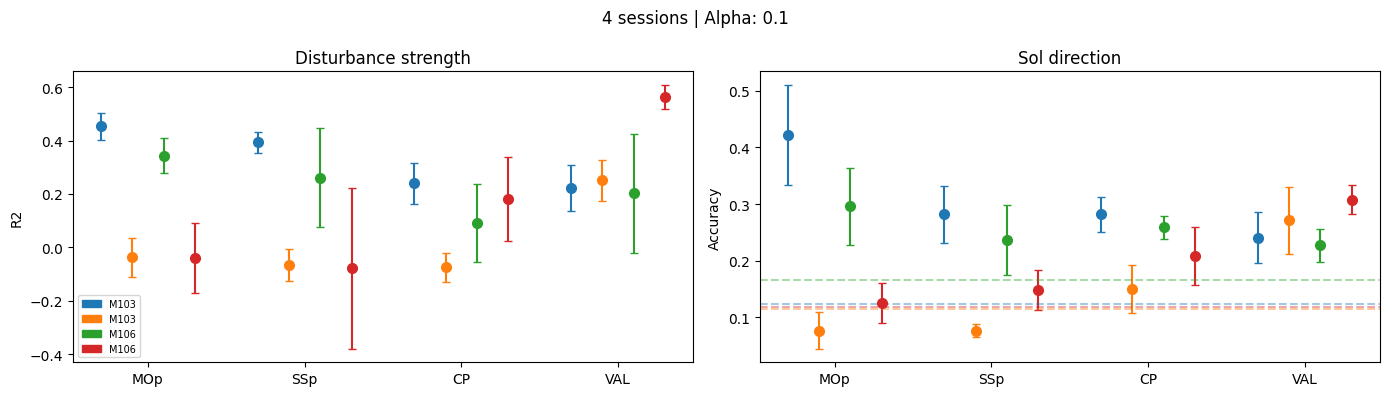

In [19]:
sessions_4 = [s for s in all_sess if all_sess[s] is not None]
areas      = Params.areas
n_sess     = len(sessions_4)

sess_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

fig, axs = plt.subplots(1, 2, figsize=(14, 4))

for ax, metric, ylabel in [
    (axs[0], "dist", "R2"),
    (axs[1], "dir",  "Accuracy"),
]:
    offsets = np.linspace(-0.3, 0.3, n_sess)
    for a_idx, area in enumerate(areas):
        for s_idx, sess in enumerate(sessions_4):
            score = sess_results_4[sess][area][metric]
            ax.errorbar(a_idx + offsets[s_idx], score.mean(), yerr=score.std(), fmt="o",
                        color=sess_colors[s_idx], capsize=3, markersize=7)

    if metric == "dir":
        for s_idx, sess in enumerate(sessions_4):
            ax.axhline(sess_results_4[sess]["chance"], color=sess_colors[s_idx],
                       linestyle="dashed", alpha=0.4)

    ax.set_xticks(range(len(areas)))
    ax.set_xticklabels(areas)
    ax.set_ylabel(ylabel)
    ax.set_title("Disturbance strength" if metric == "dist" else "Sol direction")

import matplotlib.patches as mpatches
legend_handles = [mpatches.Patch(color=sess_colors[s_idx], label=sess[:4])
                  for s_idx, sess in enumerate(sessions_4)]
axs[0].legend(handles=legend_handles, loc="best", fontsize=7)

plt.suptitle(f"4 sessions | Alpha: {alpha}")
plt.tight_layout()
plt.show()


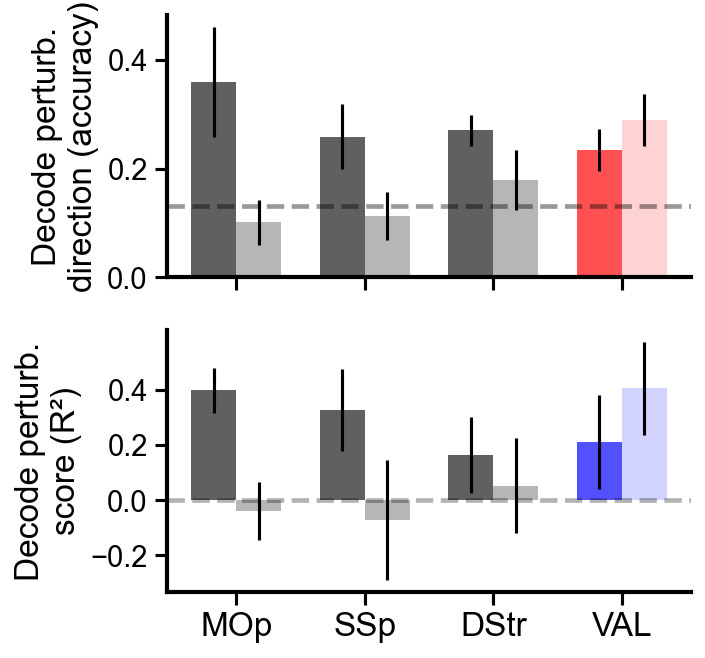

In [20]:
from tools.viz.rc_style import rc_context_talk

areas = Params.areas
bwr     = mpl.colormaps['bwr']

muscimol_sessions = {"M103_2026_02_20_16_00", "M106_2026_02_27_16_00"}
groups = {
    "normal":   [s for s in sess_results_4 if s not in muscimol_sessions],
    "muscimol": [s for s in sess_results_4 if s in muscimol_sessions],
}
group_colors = {"normal": "#444444", "muscimol": "#aaaaaa"}

# per-area color overrides — falls back to group_colors if not set
area_colors = {
    "MOp": {"normal": "#444444", "muscimol": "#aaaaaa"},
    "SSp": {"normal": "#444444", "muscimol": "#aaaaaa"},
    "CP":  {"normal": "#444444", "muscimol": "#aaaaaa"},
    "VAL": {
        "dir":  {"normal": bwr(0.9), "muscimol": bwr(0.6)},
        "dist": {"normal": bwr(0.1), "muscimol": bwr(0.4)},
    },
}

bar_width = 0.35
offsets = {"normal": -bar_width / 2, "muscimol": bar_width / 2}

with rc_context_talk():
    fig, axs = plt.subplots(2, 1, figsize=(4.5, 5), sharex=True)

    for ax, metric, ylabel in [
        (axs[0], "dir",  "Decode perturb.\ndirection (accuracy)"),
        (axs[1], "dist", "Decode perturb.\nscore (R²)"),
    ]:
        for a_idx, area in enumerate(areas):
            for gname, gsess in groups.items():
                pooled = np.concatenate([sess_results_4[s][area][metric]
                                         for s in gsess if area in sess_results_4[s]])
                c = area_colors.get(area, group_colors)
                color = c[metric][gname] if isinstance(c.get("dir"), dict) else c[gname]
                ax.bar(a_idx + offsets[gname], pooled.mean(), width=bar_width,
                       color=color, label=gname if a_idx == 0 else None,
                       yerr=pooled.std(), error_kw=dict(capsize=0, elinewidth=1.5),
                       alpha=0.85)

        if metric == "dist":
            ax.axhline(0, color="black", linestyle="dashed", alpha=0.3, linewidth=None)
            ax.set_yticks([-0.2, 0.0, 0.2, 0.4])

        if metric == "dir":
            chance_mean = np.mean([sess_results_4[s]["chance"] for s in sess_results_4])
            ax.axhline(chance_mean, color="black", linestyle="dashed", alpha=0.4)

        ax.set_xticks(range(len(areas)))
        ax.set_xticklabels(["DStr" if a == "CP" else a for a in areas])
        ax.set_ylabel(ylabel)

    fig.savefig("../../results/pdfs/muscimol_decoding.svg", bbox_inches="tight")
    plt.show()


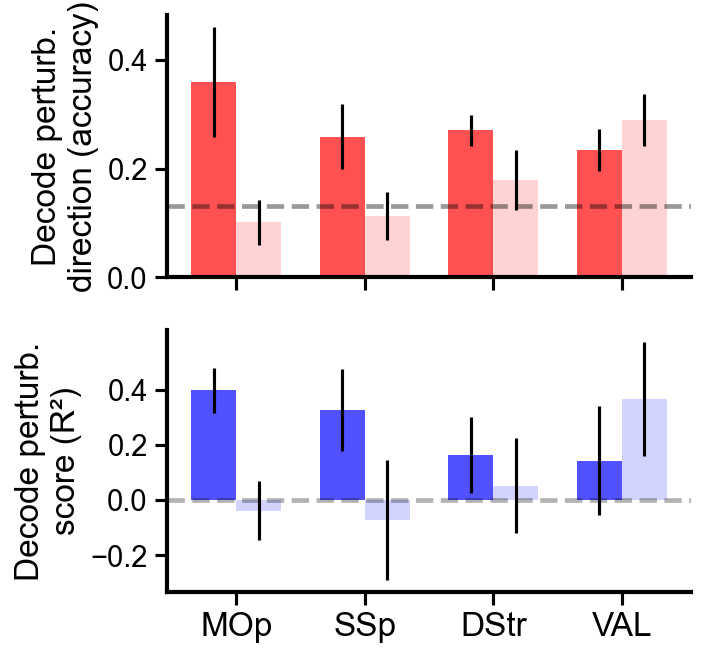

In [69]:
from tools.viz.rc_style import rc_context_talk

areas = Params.areas
bwr     = mpl.colormaps['bwr']

muscimol_sessions = {"M103_2026_02_20_16_00", "M106_2026_02_27_16_00"}
groups = {
    "normal":   [s for s in sess_results_4 if s not in muscimol_sessions],
    "muscimol": [s for s in sess_results_4 if s in muscimol_sessions],
}
group_colors = {"normal": "#444444", "muscimol": "#aaaaaa"}

area_colors = {a: {
    "dir":  {"normal": bwr(0.9), "muscimol": bwr(0.6)},
    "dist": {"normal": bwr(0.1), "muscimol": bwr(0.4)},
} for a in Params.areas}

bar_width = 0.35
offsets = {"normal": -bar_width / 2, "muscimol": bar_width / 2}

with rc_context_talk():
    fig, axs = plt.subplots(2, 1, figsize=(4.5, 5), sharex=True)

    for ax, metric, ylabel in [
        (axs[0], "dir",  "Decode perturb.\ndirection (accuracy)"),
        (axs[1], "dist", "Decode perturb.\nscore (R²)"),
    ]:
        for a_idx, area in enumerate(areas):
            for gname, gsess in groups.items():
                pooled = np.concatenate([sess_results_4[s][area][metric]
                                         for s in gsess if area in sess_results_4[s]])
                c = area_colors.get(area, group_colors)
                color = c[metric][gname] if isinstance(c.get("dir"), dict) else c[gname]
                ax.bar(a_idx + offsets[gname], pooled.mean(), width=bar_width,
                       color=color, label=gname if a_idx == 0 else None,
                       yerr=pooled.std(), error_kw=dict(capsize=0, elinewidth=1.5),
                       alpha=0.85)

        if metric == "dist":
            ax.axhline(0, color="black", linestyle="dashed", alpha=0.3, linewidth=None)
            ax.set_yticks([-0.2, 0.0, 0.2, 0.4])

        if metric == "dir":
            chance_mean = np.mean([sess_results_4[s]["chance"] for s in sess_results_4])
            ax.axhline(chance_mean, color="black", linestyle="dashed", alpha=0.4)

        ax.set_xticks(range(len(areas)))
        ax.set_xticklabels(["DStr" if a == "CP" else a for a in areas])
        ax.set_ylabel(ylabel)

    fig.savefig("../../results/pdfs/muscimol_decoding_1.svg", bbox_inches="tight")
    plt.show()


## Comparison between perturbaiton strength distributions

In [306]:
SESSIONS = [
    "M103_2026_02_18_15_30",
    "M103_2026_02_20_16_00",
    "M106_2026_02_25_15_00",
    "M106_2026_02_27_16_00",
]
all_sess_no_drop = {}
for sess in SESSIONS:
    td, _ = dsp.load_and_process_session(sess)
    all_sess_no_drop[sess] = td

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
['all_spikes', 'CP_spikes', 'MOp_spikes', 'VAL_spikes', 'SSp_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(


Resulting all_spikes ephys data shape is (NxT): (15, 48000)
Resulting CP_spikes ephys data shape is (NxT): (267, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (190, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (126, 48000)
Skipped 8 trials
Otsu immobility threshold: 6.6387
Dropped 70 of 497 rows (14.08%).
fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
['CP_spikes', 'all_spikes', 'MOp_spikes', 'SSp_spikes', 'VAL_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.90029910269193% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.90029910269193% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.90029910269193% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.90029910269193% of trials
  warnings.warn(


Resulting CP_spikes ephys data shape is (NxT): (136, 48000)
Resulting all_spikes ephys data shape is (NxT): (18, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (65, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (43, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (164, 48000)
Skipped 36 trials
Otsu immobility threshold: 1.8090
Dropped 17 of 500 rows (3.40%).
fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
['CP_spikes', 'MOp_spikes', 'all_spikes', 'VAL_spikes', 'SSp_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(


Resulting CP_spikes ephys data shape is (NxT): (206, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (156, 48000)
Resulting all_spikes ephys data shape is (NxT): (11, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (132, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (142, 48000)
add_concat_perturb_time: dropping 1 trial(s) with missing idx_sol_on
Skipped 87 trials
Otsu immobility threshold: 2.2123
Dropped 130 of 499 rows (26.05%).
fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
['CP_spikes', 'MOp_spikes', 'all_spikes', 'SSp_spikes', 'VAL_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.89939637826963% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.89939637826963% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.89939637826963% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.89939637826963% of trials
  warnings.warn(


Resulting CP_spikes ephys data shape is (NxT): (118, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (49, 48000)
Resulting all_spikes ephys data shape is (NxT): (7, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (37, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (166, 48000)
add_concat_perturb_time: dropping 1 trial(s) with missing idx_sol_on
Skipped 21 trials
Otsu immobility threshold: 2.0868
Dropped 32 of 495 rows (6.46%).


In [329]:
scores.shape

(425, 12)

In [338]:
Params.oscillating_key_points[4]

'left_paw'

  drop_trials_sem_crosses_zero: by SEM: 258  |  by value: 424  |  kept: 257/425 (60.5%)
M103_2026_02_18_15_30  n=257  median=-0.195  mean=-0.237  std=0.206
  drop_trials_sem_crosses_zero: by SEM: 280  |  by value: 454  |  kept: 278/456 (61.0%)
M103_2026_02_20_16_00  n=278  median=-0.283  mean=-0.329  std=0.261
  drop_trials_sem_crosses_zero: by SEM: 208  |  by value: 309  |  kept: 192/325 (59.1%)
M106_2026_02_25_15_00  n=192  median=-0.309  mean=-0.416  std=0.381
  drop_trials_sem_crosses_zero: by SEM: 306  |  by value: 427  |  kept: 279/454 (61.5%)
M106_2026_02_27_16_00  n=279  median=-0.202  mean=-0.295  std=0.299


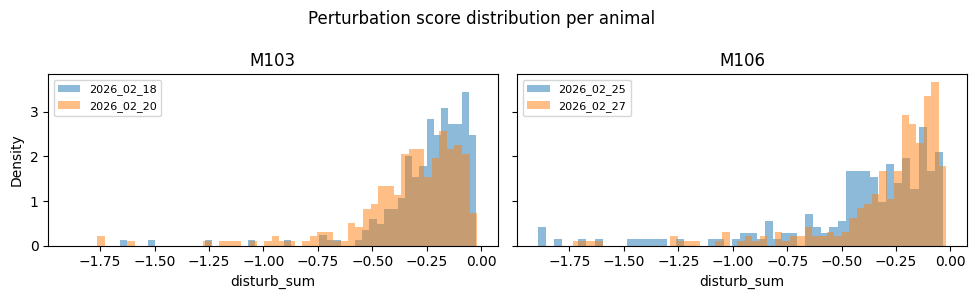

In [349]:
from itertools import groupby

sessions_4  = [s for s in all_sess_no_drop if all_sess_no_drop[s] is not None]
sess_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

# Group sessions by animal ID (first 4 chars)
from collections import defaultdict
animals = defaultdict(list)
for sess in sessions_4:
    animals[sess[:4]].append(sess)

fig, axs = plt.subplots(1, len(animals), figsize=(10, 3), sharey=True, sharex=True)
if len(animals) == 1:
    axs = [axs]

for ax, (animal, sess_list) in zip(axs, animals.items()):
    for sess, clr in zip(sess_list, sess_colors):
        td_dropped = dsp.drop_trials_sem_crosses_zero(all_sess_no_drop[sess], std=False)
        scores = td_dropped.disturb_mean.values
        label  = sess[5:15]  # date portion
        ax.hist(scores, bins=50, color=clr, alpha=0.5, density=True, label=label)
        # ax.axvline(np.median(scores), color=clr, linewidth=2, linestyle="--")
        print(f"{sess}  n={len(scores)}  median={np.median(scores):.3f}  mean={scores.mean():.3f}  std={scores.std():.3f}")
    ax.set_title(animal)
    ax.set_xlabel("disturb_sum")
    # ax.set_xlim([-2, 2])
    ax.legend(fontsize=8)

axs[0].set_ylabel("Density")
plt.suptitle("Perturbation score distribution per animal")
plt.tight_layout()
plt.show()


M103_2026_02_18_15_30  n=206  median=-0.233  mean=-0.277  std=0.210
M103_2026_02_20_16_00  n=179  median=-0.353  mean=-0.418  std=0.278
M106_2026_02_25_15_00  n=151  median=-0.379  mean=-0.497  std=0.389
M106_2026_02_27_16_00  n=197  median=-0.273  mean=-0.375  std=0.320


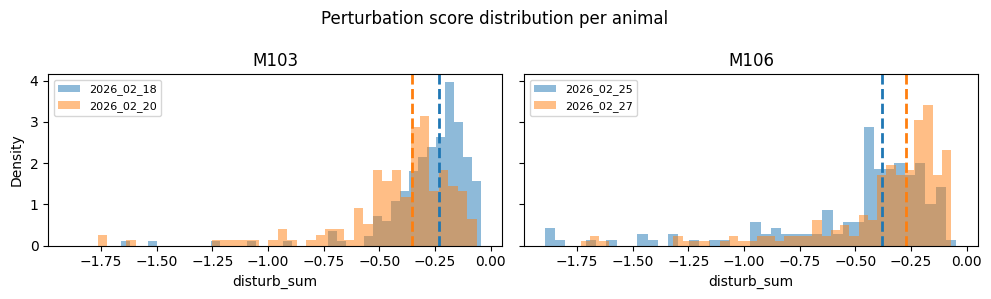

In [297]:
from itertools import groupby

sessions_4  = [s for s in all_sess if all_sess[s] is not None]
sess_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

# Group sessions by animal ID (first 4 chars)
from collections import defaultdict
animals = defaultdict(list)
for sess in sessions_4:
    animals[sess[:4]].append(sess)

fig, axs = plt.subplots(1, len(animals), figsize=(10, 3), sharey=True, sharex=True)
if len(animals) == 1:
    axs = [axs]

for ax, (animal, sess_list) in zip(axs, animals.items()):
    for sess, clr in zip(sess_list, sess_colors):
        scores = all_sess[sess]["td"].disturb_mean.values
        label  = sess[5:15]  # date portion
        ax.hist(scores, bins=40, color=clr, alpha=0.5, density=True, label=label)
        ax.axvline(np.median(scores), color=clr, linewidth=2, linestyle="--")
        print(f"{sess}  n={len(scores)}  median={np.median(scores):.3f}  mean={scores.mean():.3f}  std={scores.std():.3f}")
    ax.set_title(animal)
    ax.set_xlabel("disturb_sum")
    ax.legend(fontsize=8)

axs[0].set_ylabel("Density")
plt.suptitle("Perturbation score distribution per animal")
plt.tight_layout()
plt.show()


# Motor potent - null from VAL

In [5]:
del all_sess_no_drop

In [4]:
SESSIONS = [
    "M103_2026_02_18_15_30",
    "M103_2026_02_20_16_00",
    "M106_2026_02_25_15_00",
    "M106_2026_02_27_16_00",
]
all_sess_no_drop = {}
for sess in SESSIONS:
    td, _ = dsp.load_and_process_session(sess)
    all_sess_no_drop[sess] = td

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
['all_spikes', 'CP_spikes', 'MOp_spikes', 'VAL_spikes', 'SSp_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(


Resulting all_spikes ephys data shape is (NxT): (15, 48000)
Resulting CP_spikes ephys data shape is (NxT): (267, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (190, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (126, 48000)
Skipped 8 trials
Otsu immobility threshold: 6.6387
Dropped 70 of 497 rows (14.08%).
fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
['CP_spikes', 'all_spikes', 'MOp_spikes', 'SSp_spikes', 'VAL_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.90029910269193% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.90029910269193% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.90029910269193% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.90029910269193% of trials
  warnings.warn(


Resulting CP_spikes ephys data shape is (NxT): (136, 48000)
Resulting all_spikes ephys data shape is (NxT): (18, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (65, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (43, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (164, 48000)
Skipped 36 trials
Otsu immobility threshold: 1.8090
Dropped 17 of 500 rows (3.40%).
fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
['CP_spikes', 'MOp_spikes', 'all_spikes', 'VAL_spikes', 'SSp_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(


Resulting CP_spikes ephys data shape is (NxT): (206, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (156, 48000)
Resulting all_spikes ephys data shape is (NxT): (11, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (132, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (142, 48000)
add_concat_perturb_time: dropping 1 trial(s) with missing idx_sol_on
Skipped 87 trials
Otsu immobility threshold: 2.2123
Dropped 130 of 499 rows (26.05%).
fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
['CP_spikes', 'MOp_spikes', 'all_spikes', 'SSp_spikes', 'VAL_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.89939637826963% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.89939637826963% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.89939637826963% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.89939637826963% of trials
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
sess = 'M103_2026_02_18_15_30'
td = all_sess_no_drop[sess]

area_x = 'VAL'
area_y = 'bhv'
origin_rank=50

td_potent_null = subspaces.compute_potent_null_td(
    td_=td,
    signal_x=f'{area_x}_rates_pca',
    signal_y=f'{area_y}_rates_pca',
    origin_rank=origin_rank,
    target_rank=36,
    n_iter=2
)

NameError: name 'all_sess_no_drop' is not defined

# Check orthogonal subspaces

In [4]:
SESSIONS = [
    # "M061_2025_03_04_10_00",
    # "M061_2025_03_05_14_00",
    # "M061_2025_03_06_14_00",
    # "M063_2025_03_13_14_00",
    # "M063_2025_03_14_15_30",
    # "M062_2025_03_20_14_00",
    # "M062_2025_03_21_14_00",
    "M078_2025_08_06_15_00",
    # "M086_2025_12_10_15_00",
    # "M103_2026_02_18_15_30",
    # "M103_2026_02_19_15_30",
    # "M106_2026_02_25_15_00",
    # "M106_2026_02_26_16_00",
]
all_sess_no_drop = {}
for sess in SESSIONS:
    td, _ = dsp.load_and_process_session(sess, std=0.03)
    all_sess_no_drop[sess] = td

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'idx_motion', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
['SSp_spikes', 'all_spikes', 'VAL_spikes', 'MOs_spikes', 'CP_spikes', 'MOp_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of SSp_spikes on 99.9003984063745% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of SSp_spikes on 99.9003984063745% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of SSp_spikes on 99.9003984063745% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of SSp_spikes on 99.9003984063745% of trials
  warnings.warn(


Resulting SSp_spikes ephys data shape is (NxT): (90, 48000)
Resulting all_spikes ephys data shape is (NxT): (54, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (192, 48000)
Resulting MOs_spikes ephys data shape is (NxT): (172, 48000)
Resulting CP_spikes ephys data shape is (NxT): (151, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (83, 48000)
Skipped 107 trials
Otsu immobility threshold: 2.2837
Dropped 83 of 501 rows (16.57%).


/home/me24/repos/earthquake-analysis/notebooks/standardising/../../tools/dsp/preprocessing.py:193: RuntimeWarning: divide by zero encountered in log10
  lambda a: np.log10(np.abs(np.sum(a)))


In [5]:
perturb_td = pyal.restrict_to_interval(td, start_point_name='idx_sol_on', rel_start=-200, rel_end=300)
perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)
td_drop = dsp.drop_trials_sem_crosses_zero(perturb_td_shuff, std=False)
td_drop.loc[:, 'power'] = td_drop.apply(
        lambda row: row['power'][row["concat_perturb_time"] - 200:row["concat_perturb_time"] + 301, :],
        axis=1
    )

/tmp/ipykernel_3732845/3062433816.py:1: UserWarning: Dropping 1 trials because of invalid time indexing. For more information, try warn_per_trial=True
  perturb_td = pyal.restrict_to_interval(td, start_point_name='idx_sol_on', rel_start=-200, rel_end=300)


  drop_trials_sem_crosses_zero: by SEM: 296  |  by value: 364  |  kept: 296/364 (81.3%)


In [270]:
# ── Optional: balance direction classes by undersampling ──────────────────────
# Run this cell to override td_drop with a class-balanced version.
# Randomly selects min_count trials per direction class.

from sklearn.utils import resample

rng_bal = np.random.default_rng(42)
labels  = td_drop.values_Sol_direction.values
classes, counts = np.unique(labels, return_counts=True)
min_count = counts.min()

print(f'Before balancing: {dict(zip(classes.astype(int), counts))}')
print(f'Undersampling each class to {min_count} trials')

balanced_idx = np.concatenate([
    rng_bal.choice(np.where(labels == c)[0], size=min_count, replace=False)
    for c in classes
])
balanced_idx = np.sort(balanced_idx)

td_drop = td_drop.iloc[balanced_idx].reset_index(drop=True)

labels_bal = td_drop.values_Sol_direction.values
_, counts_bal = np.unique(labels_bal, return_counts=True)
print(f'After balancing:  {len(td_drop)} trials total, {counts_bal[0]} per class')


Before balancing: {0: 12, 1: 25, 2: 25, 3: 19, 4: 13, 5: 23, 6: 14, 7: 12, 8: 20, 9: 23, 10: 20, 11: 15}
Undersampling each class to 12 trials
After balancing:  144 trials total, 12 per class


In [6]:
td_drop.head()

,index,animal,session,trial_id,trial_name,trial_length,bin_size,idx_trial_start,idx_trial_end,idx_CPI,...,MOp_rates_pca,bhv,bhv_concat,concat_perturb_time,concat_trial_start,power,phases,disturb_score,disturb_mean,disturb_sum
0,193,M078,M078_2025_08_06_15_00,570,trial,600,0.01,NaN,NaN,[],...,"[[-33.979748, -1.40979, -19.674536, 11.698748,...","[[6.561183873902643, 15.983201584541655, 197.1...","[[202.55708117693783, 183.50860731684585, 196....",300,100,"[[2.2660624960851083, 1.6477817240454289, 2.68...","[[1.3961352223670886, 0.7943515363696845, 1.45...","[-0.7522013079255379, -0.812916941081212, -0.8...",-0.861993,1.014685
2,15,M078,M078_2025_08_06_15_00,54,trial,600,0.01,NaN,NaN,[],...,"[[0.04045105, -15.585053, 10.352032, 1.8552284...","[[13.186865439612824, 16.498066732819424, 189....","[[201.6084697570983, 179.35876405962833, 202.4...",700,500,"[[2.4269404876662, 1.5287402875459322, 2.43892...","[[-1.800497178447038, 1.8591133256506807, -2.2...","[-0.29626475666658325, -0.1752405727682322, -0...",-0.266082,0.504197
4,57,M078,M078_2025_08_06_15_00,204,trial,600,0.01,NaN,NaN,[],...,"[[23.198868, -8.121468, 20.930573, 4.5484715, ...","[[21.09468336734454, 17.771805257257927, 207.5...","[[200.3023041232557, 179.12321134387773, 197.0...",300,100,"[[2.3386450451499305, 1.6710025044591024, 2.78...","[[-1.5278435373597268, 2.4252882107378992, -1....","[-0.22957020510234208, -0.35153000193898765, -...",-0.321823,0.586798
5,183,M078,M078_2025_08_06_15_00,546,trial,600,0.01,NaN,NaN,[],...,"[[-8.7408695, 14.375759, 28.726013, 26.034403,...","[[10.922685741505417, 15.000487059018637, 207....","[[197.57031186692885, 182.29678560255385, 191....",300,100,"[[2.437934630279643, 1.696908171592852, 2.7581...","[[1.9624248695747681, 1.4200054572883705, 2.65...","[-0.12000794677980955, -0.19421194297557087, -...",-0.180100,0.334694
6,76,M078,M078_2025_08_06_15_00,250,trial,600,0.01,NaN,NaN,[],...,"[[79.30232, 24.852005, -43.40022, 25.54101, -2...","[[12.69216626652422, 15.48020015883265, 199.97...","[[201.47133242343708, 183.0994156869246, 196.3...",700,500,"[[2.492507167676528, 1.63640089907607, 2.76409...","[[1.5457300558259381, 1.0280602260159735, 1.54...","[-0.17522757360292915, -0.1843099918246594, -0...",-0.129959,0.192986


In [7]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.utils import resample


def get_lda_axes(X_epoch, labels, k=11, shrinkage='auto'):
    """
    Fit LDA and return orthonormal discriminant axes.
    solver='eigen' supports shrinkage and provides scalings_.

    k : number of top discriminant axes to return (default 1).
        Pass k=None to return all n_classes-1 axes.
    Returns Q: (n_features, k) orthonormal columns.
    """
    lda = LinearDiscriminantAnalysis()
    lda.fit(X_epoch, labels)
    W = lda.scalings_          # (n_features, n_classes - 1)
    # if k is not None:
    #     W = W[:, :k]
    Q, _ = np.linalg.qr(W)
    return Q


def iterative_null_projection(X, Q):
    """
    Remove axes Q[:,0], Q[:,1], ... from X using I - ww^T.
    X: (..., N), Q: (N, K) orthonormal columns.
    Returns X_null with same shape as X.
    """
    X_null = X.copy().astype(float)
    for k in range(Q.shape[1]):
        w = Q[:, k]
        P = np.eye(len(w)) - np.outer(w, w)
        X_null = X_null @ P
    return X_null


## Clean up version

In [11]:
# ── Parameters ────────────────────────────────────────────────────────────────
area        = 'MOs'
origin_rank = 30
window  = (200, 250)
alpha_ridge = 0.01
n_splits    = 4

# ── Data ──────────────────────────────────────────────────────────────────────
X_full  = np.stack(td_drop[f'{area}_rates_pca'].values)[:, :, :origin_rank]
X_rates = np.concatenate(td_drop[f'{area}_rates'].values)
y_dir   = np.array(td_drop.values_Sol_direction.values.tolist())
# y_dir   = np.array([Params.sol_dir_to_angle[val] for val in y_dir])

y_dist  = td_drop.disturb_sum.values.astype(float)
# y_dist = np.stack(td_drop.disturb_score.values)

_, _counts = np.unique(y_dir, return_counts=True)
chance     = _counts.max() / _counts.sum()
var_pop    = np.trace(np.cov(X_rates.T))

rng     = np.random.default_rng(42)
cv_dir  = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=40)
cv_dist = KFold(n_splits=n_splits, shuffle=True, random_state=40)

# ── Baseline scores (full space) ──────────────────────────────────────────────
X_dir_ep  = X_full[:, window[0]:window[1],  :].mean(axis=1)
X_dist_ep = X_full[:, window[0]:window[1],:].mean(axis=1)

y_shuf_bl = rng.permutation(y_dist)
dir_full, dist_full, dist_lb = [], [], []
for tr, te in cv_dir.split(X_dir_ep, y_dir):
    clf = LinearDiscriminantAnalysis()
    clf.fit(X_dir_ep[tr], y_dir[tr])
    dir_full.append(clf.score(X_dir_ep[te], y_dir[te]))
for tr, te in cv_dist.split(X_dist_ep):
    reg = Ridge(alpha_ridge)
    reg.fit(X_dist_ep[tr], y_dist[tr])
    dist_full.append(decode.custom_r2_func(y_dist[te], reg.predict(X_dist_ep[te])))
    dist_lb.append(  decode.custom_r2_func(y_shuf_bl[te], reg.predict(X_dist_ep[te])))

print(f'{area}  |  neurons: {X_rates.shape[1]}  origin_rank: {origin_rank}  trials: {len(y_dir)}')
print(f'Baseline  direction acc = {np.mean(dir_full):.3f} +/- {np.std(dir_full):.3f}  (chance={chance:.3f})')
print(f'Baseline  disturb   R2  = {np.mean(dist_full):.3f} +/- {np.std(dist_full):.3f}  (lb={np.mean(dist_lb):.3f})')
print(f'var_pop = {var_pop:.2f}  |  top-{origin_rank} PCs = {np.trace(np.cov(X_full.reshape(-1,origin_rank).T)):.2f}  '
      f'({np.trace(np.cov(X_full.reshape(-1,origin_rank).T))/var_pop*100:.1f}% of pop)')


MOs  |  neurons: 172  origin_rank: 30  trials: 296
Baseline  direction acc = 0.149 +/- 0.045  (chance=0.111)
Baseline  disturb   R2  = 0.495 +/- 0.047  (lb=0.000)
var_pop = 6656.10  |  top-30 PCs = 3176.22  (47.7% of pop)


In [12]:
def _decode_dir(X_ep, y, cv):
    scores = []
    for tr, te in cv.split(X_ep, y):
        clf = LinearDiscriminantAnalysis()
        clf.fit(X_ep[tr], y[tr])
        scores.append(clf.score(X_ep[te], y[te]))
    return scores

def _decode_dist(X_ep, y, y_shuf, cv, alpha):
    scores, lb = [], []
    for tr, te in cv.split(X_ep):
        reg = Ridge(alpha)
        reg.fit(X_ep[tr], y[tr])
        scores.append(decode.custom_r2_func(y[te],      reg.predict(X_ep[te])))
        lb.append(    decode.custom_r2_func(y_shuf[te], reg.predict(X_ep[te])))
    return scores, lb

def run_iterative_removal(X_full, get_axes_fn, y_dir, y_dist,
                           dir_window, dist_window, alpha_ridge, n_iter,
                           cv_dir, cv_dist, rng, var_pop, origin_rank):
    """
    Iteratively project X onto the null of axes returned by get_axes_fn.

    get_axes_fn(X_dir_ep, X_dist_ep) -> axes array (n_features, k)

    Returns dict with lists of length n_iter+1 (iter 0 = full space):
      dir, dist, lb    — per-fold score lists
      var_pca          — fraction of top-origin_rank variance remaining (whole array)
      var_pop          — fraction of full population variance remaining (whole array)
      var_dir_ep_pca   — fraction of dir-window epoch variance remaining (re top-origin_rank PCs)
      var_dist_ep_pca  — fraction of dist-window epoch variance remaining (re top-origin_rank PCs)
    """
    y_shuf    = rng.permutation(y_dist)
    X_iter    = X_full.copy()
    var_base  = np.trace(np.cov(X_full.reshape(-1, origin_rank).T))
    var_dir_base  = np.trace(np.cov(X_full[:, dir_window[0]:dir_window[1],  :].mean(axis=1).T))
    var_dist_base = np.trace(np.cov(X_full[:, dist_window[0]:dist_window[1],:].mean(axis=1).T))
    res = dict(dir=[], dist=[], lb=[], var_pca=[], var_pop=[],
               var_dir_ep=[], var_dist_ep=[])

    for i in range(n_iter + 1):
        X_dir_ep  = X_iter[:, dir_window[0]:dir_window[1],  :].mean(axis=1)
        X_dist_ep = X_iter[:, dist_window[0]:dist_window[1],:].mean(axis=1)

        res['dir'].append(_decode_dir(X_dir_ep, y_dir, cv_dir))
        d, lb = _decode_dist(X_dist_ep, y_dist, y_shuf, cv_dist, alpha_ridge)
        res['dist'].append(d); res['lb'].append(lb)

        # whole-array variance
        var_i = np.trace(np.cov(X_iter.reshape(-1, origin_rank).T))
        res['var_pca'].append(var_i / var_base)
        res['var_pop'].append(var_i / var_pop)

        # epoch-window variance
        res['var_dir_ep'].append( np.trace(np.cov(X_dir_ep.T))  / var_dir_base)
        res['var_dist_ep'].append(np.trace(np.cov(X_dist_ep.T)) / var_dist_base)

        if i < n_iter:
            axes   = get_axes_fn(X_dir_ep, X_dist_ep)
            X_iter = np.array([iterative_null_projection(t, axes) for t in X_iter])

        m_dir  = np.mean(res['dir'][-1]);  s_dir  = np.std(res['dir'][-1])
        m_dist = np.mean(res['dist'][-1]); s_dist = np.std(res['dist'][-1])
        m_lb   = np.mean(res['lb'][-1])
        print(f'  iter {i}  dir={m_dir:.3f}±{s_dir:.3f}  dist={m_dist:.3f}±{s_dist:.3f} (lb={m_lb:.3f})'
              f'  var_array={res["var_pca"][-1]*100:.1f}%'
              f'  var_dir_ep={res["var_dir_ep"][-1]*100:.1f}%'
              f'  var_dist_ep={res["var_dist_ep"][-1]*100:.1f}%')

    return res


── Direction removal ─────────────────────────────────
  iter 0  dir=0.149±0.045  dist=0.495±0.047 (lb=0.010)  var_array=100.0%  var_dir_ep=100.0%  var_dist_ep=100.0%
  iter 1  dir=0.044±0.011  dist=0.358±0.057 (lb=0.009)  var_array=68.6%  var_dir_ep=73.0%  var_dist_ep=73.0%
  iter 2  dir=0.044±0.011  dist=0.360±0.064 (lb=0.010)  var_array=37.0%  var_dir_ep=44.5%  var_dist_ep=44.5%
  iter 3  dir=0.044±0.011  dist=0.356±0.071 (lb=0.011)  var_array=33.6%  var_dir_ep=41.2%  var_dist_ep=41.2%
  iter 4  dir=0.041±0.010  dist=0.326±0.060 (lb=0.010)  var_array=32.7%  var_dir_ep=40.2%  var_dist_ep=40.2%
── Disturbance removal ───────────────────────────────
  iter 0  dir=0.149±0.045  dist=0.495±0.047 (lb=0.015)  var_array=100.0%  var_dir_ep=100.0%  var_dist_ep=100.0%
  iter 1  dir=0.159±0.037  dist=0.120±0.014 (lb=0.036)  var_array=96.7%  var_dir_ep=95.0%  var_dist_ep=95.0%
  iter 2  dir=0.159±0.037  dist=0.120±0.014 (lb=0.036)  var_array=94.4%  var_dir_ep=92.5%  var_dist_ep=92.5%
  iter 3  di

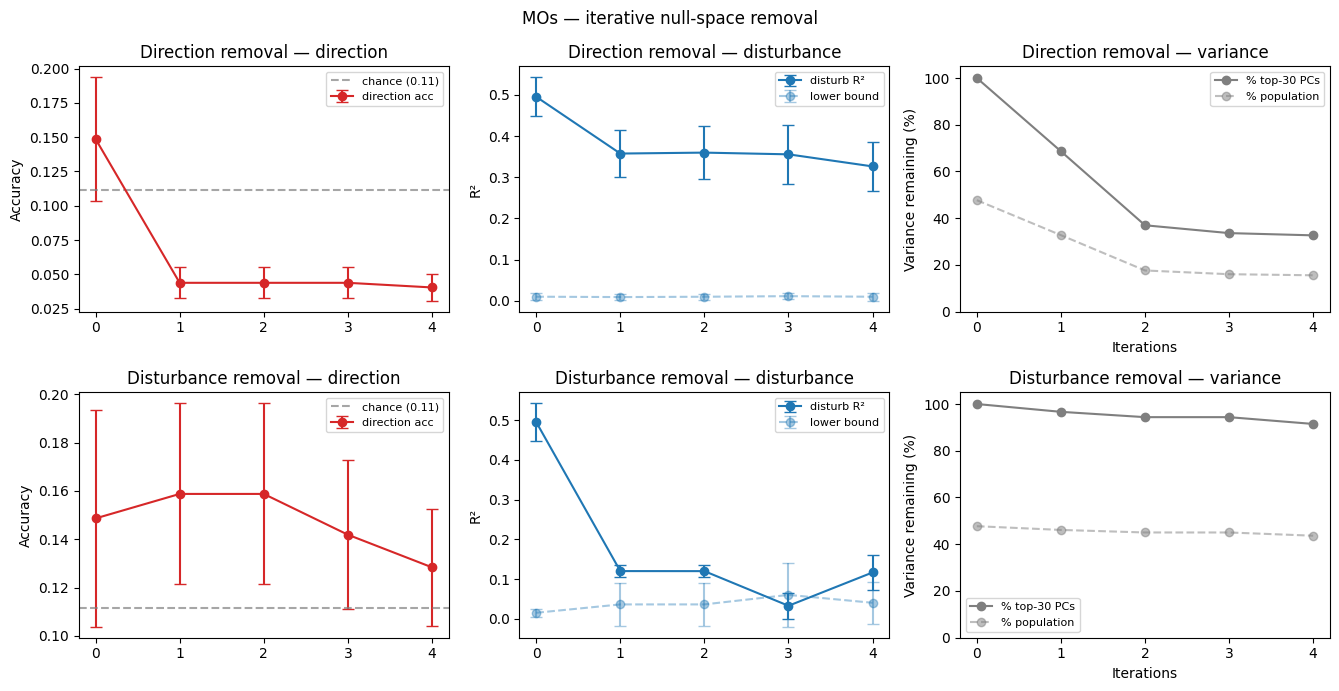

In [13]:
def _dir_axes(X_dir_ep, X_dist_ep):
    return get_lda_axes(X_dir_ep, y_dir)

def _dist_axis(X_dir_ep, X_dist_ep):
    reg = Ridge(alpha_ridge)
    reg.fit(X_dist_ep, y_dist)
    w = reg.coef_.ravel()
    return (w / np.linalg.norm(w))[:, None]


n_iter_dir  = 4   # iterations for direction removal
n_iter_dist = 4   # iterations for disturbance removal
show_var    = True

print('── Direction removal ─────────────────────────────────')
res_dir  = run_iterative_removal(X_full, _dir_axes, y_dir, y_dist,
                                  window, window, alpha_ridge, n_iter_dir,
                                  cv_dir, cv_dist, rng, var_pop, origin_rank)

print('── Disturbance removal ───────────────────────────────')
res_dist = run_iterative_removal(X_full, _dist_axis, y_dir, y_dist,
                                  window, window, alpha_ridge, n_iter_dist,
                                  cv_dir, cv_dist, rng, var_pop, origin_rank)

# ── Plot ──────────────────────────────────────────────────────────────────────
def _mean(lst): return [np.mean(x) for x in lst]
def _std(lst):  return [np.std(x)  for x in lst]

n_cols = 3 if show_var else 2
fig, axs = plt.subplots(2, n_cols, figsize=(4.5*n_cols, 7))

for row, (res, title) in enumerate([(res_dir, 'Direction removal'), (res_dist, 'Disturbance removal')]):
    iters = np.arange(len(res['dir']))
    axs[row, 0].errorbar(iters, _mean(res['dir']), yerr=_std(res['dir']),
                         fmt='o-', color='tab:red', capsize=4, label='direction acc')
    axs[row, 0].axhline(chance, color='gray', ls='--', alpha=0.7, label=f'chance ({chance:.2f})')
    axs[row, 0].set_ylabel('Accuracy'); axs[row, 0].set_title(f'{title} — direction')
    axs[row, 0].legend(fontsize=8)

    axs[row, 1].errorbar(iters, _mean(res['dist']), yerr=_std(res['dist']),
                         fmt='o-', color='tab:blue', capsize=4, label='disturb R²')
    axs[row, 1].errorbar(iters, _mean(res['lb']), yerr=_std(res['lb']),
                         fmt='o--', color='tab:blue', alpha=0.4, capsize=4, label='lower bound')
    axs[row, 1].set_ylabel('R²'); axs[row, 1].set_title(f'{title} — disturbance')
    axs[row, 1].legend(fontsize=8)

    if show_var:
        axs[row, 2].plot(iters, [v*100 for v in res['var_pca']], 'o-',  color='tab:gray', label=f'% top-{origin_rank} PCs')
        axs[row, 2].plot(iters, [v*100 for v in res['var_pop']], 'o--', color='tab:gray', alpha=0.5, label='% population')
        axs[row, 2].set_ylabel('Variance remaining (%)'); axs[row, 2].set_ylim(0, 105)
        axs[row, 2].set_title(f'{title} — variance'); axs[row, 2].legend(fontsize=8)

    axs[row, -1].set_xlabel('Iterations')

plt.suptitle(f'{area} — iterative null-space removal', fontsize=12)
plt.tight_layout()
plt.show()


### Across all areas


── MOp (dir_iters=2, dist_iters=5) ──
  direction removal:
  iter 0  dir=0.366±0.053  dist=0.380±0.088 (lb=0.010)  var_array=100.0%  var_dir_ep=100.0%  var_dist_ep=100.0%
  iter 1  dir=0.250±0.048  dist=0.000±0.000 (lb=0.000)  var_array=0.0%  var_dir_ep=0.0%  var_dist_ep=0.0%
  iter 2  dir=0.222±0.054  dist=0.000±0.000 (lb=0.000)  var_array=0.0%  var_dir_ep=0.0%  var_dist_ep=0.0%
  disturbance removal:
  iter 0  dir=0.366±0.053  dist=0.380±0.088 (lb=0.018)  var_array=100.0%  var_dir_ep=100.0%  var_dist_ep=100.0%
  iter 1  dir=0.370±0.057  dist=0.165±0.049 (lb=0.013)  var_array=97.1%  var_dir_ep=97.9%  var_dist_ep=97.9%
  iter 2  dir=0.370±0.057  dist=0.165±0.049 (lb=0.013)  var_array=93.6%  var_dir_ep=95.1%  var_dist_ep=95.1%
  iter 3  dir=0.375±0.079  dist=0.056±0.029 (lb=0.018)  var_array=93.6%  var_dir_ep=95.1%  var_dist_ep=95.1%
  iter 4  dir=0.407±0.065  dist=0.005±0.005 (lb=0.024)  var_array=90.3%  var_dir_ep=92.4%  var_dist_ep=92.4%
  iter 5  dir=0.407±0.065  dist=0.005±0.005 (

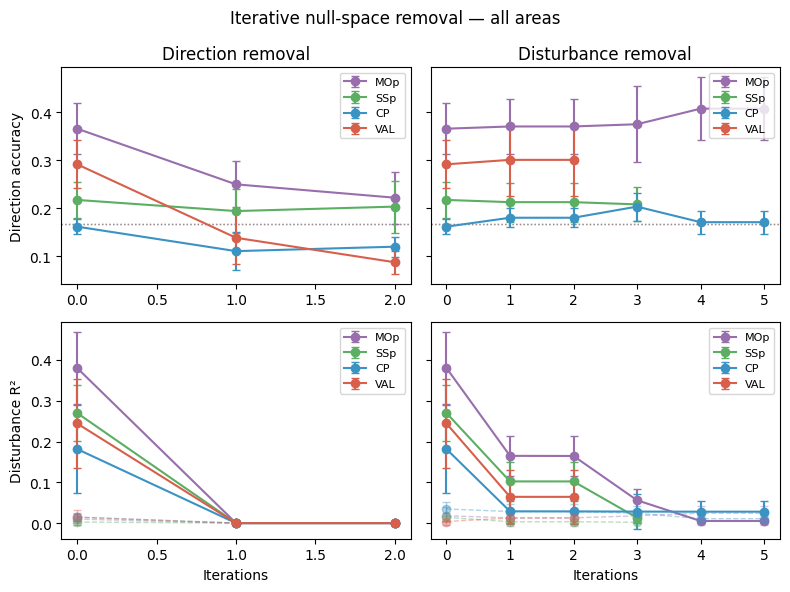

In [15]:
# ── Run iterative removal across all areas ────────────────────────────────────
dir_window  = (200, 250)
dist_window = (200, 250)
alpha_ridge = 0.01
n_splits    = 4

# Iterations per area per condition — edit here
n_iters = {
    #  area  : (n_iter_dir, n_iter_dist)
    'MOp': (2, 5),
    'SSp': (2, 3),
    'CP' : (2, 5),
    'VAL': (2, 2),
}
pc_dict = {
    "MOp": 30,
    "SSp": 25,
    "CP": 30,
    "VAL": 50,
}

cv_dir  = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=40)
cv_dist = KFold(n_splits=n_splits, shuffle=True, random_state=40)
rng     = np.random.default_rng(42)

results_by_area = {}

for area in Params.areas:
    n_iter_dir, n_iter_dist = n_iters[area]

    X_full_a  = np.stack(td_drop[f'{area}_rates_pca'].values)[:, :, :pc_dict[area]]
    X_rates_a = np.concatenate(td_drop[f'{area}_rates'].values)
    y_dir_a   = np.array(td_drop.values_Sol_direction.values.tolist())
    y_dist_a  = td_drop.disturb_sum.values.astype(float)
    var_pop_a = np.trace(np.cov(X_rates_a.T))

    def _dir_axes_a(X_dir_ep, X_dist_ep):
        return get_lda_axes(X_dir_ep, y_dir_a)

    def _dist_axis_a(X_dir_ep, X_dist_ep):
        reg = Ridge(alpha_ridge)
        reg.fit(X_dist_ep, y_dist_a)
        w = reg.coef_.ravel()
        return (w / np.linalg.norm(w))[:, None]

    print(f'\n── {area} (dir_iters={n_iter_dir}, dist_iters={n_iter_dist}) ──')
    print('  direction removal:')
    res_dir_a  = run_iterative_removal(X_full_a, _dir_axes_a, y_dir_a, y_dist_a,
                                        dir_window, dist_window, alpha_ridge, n_iter_dir,
                                        cv_dir, cv_dist, rng, var_pop_a, pc_dict[area])
    print('  disturbance removal:')
    res_dist_a = run_iterative_removal(X_full_a, _dist_axis_a, y_dir_a, y_dist_a,
                                        dir_window, dist_window, alpha_ridge, n_iter_dist,
                                        cv_dir, cv_dist, rng, var_pop_a, pc_dict[area])

    _, _counts = np.unique(y_dir_a, return_counts=True)
    results_by_area[area] = dict(
        dir_removal=res_dir_a,
        dist_removal=res_dist_a,
        chance=_counts.max() / _counts.sum(),
    )

# ── Plot: 2×2 — columns = removal condition, rows = decoded variable ──────────
def _mean(lst): return [np.mean(x) for x in lst]
def _std(lst):  return [np.std(x)  for x in lst]

fig, axs = plt.subplots(2, 2, figsize=(8, 6), sharey='row')

col_keys    = ['dir_removal',       'dist_removal']
col_labels  = ['Direction removal', 'Disturbance removal']

for col, (removal_key, col_label) in enumerate(zip(col_keys, col_labels)):
    for area in Params.areas:
        res     = results_by_area[area][removal_key]
        chance  = results_by_area[area]['chance']
        c_light = getattr(colors, f'{area}_light')
        iters   = np.arange(len(res['dir']))

        # Row 0: direction decoding (dark colour)
        axs[0, col].errorbar(iters, _mean(res['dir']), yerr=_std(res['dir']),
                             fmt='o-', color=c_light, capsize=3, label=area, lw=1.5)
        axs[0, col].axhline(chance, color=c_light, ls=':', alpha=0.4, lw=1)

        # Row 1: disturbance decoding (light colour)
        axs[1, col].errorbar(iters, _mean(res['dist']), yerr=_std(res['dist']),
                             fmt='o-', color=c_light, capsize=3, label=area, lw=1.5)
        axs[1, col].errorbar(iters, _mean(res['lb']), yerr=_std(res['lb']),
                             fmt='o--', color=c_light, alpha=0.4, capsize=3, lw=1)

    axs[0, col].set_title(col_label)
    axs[0, col].legend(fontsize=8, loc='upper right')
    axs[1, col].legend(fontsize=8, loc='upper right')
    axs[1, col].set_xlabel('Iterations')

axs[0, 0].set_ylabel('Direction accuracy')
axs[1, 0].set_ylabel('Disturbance R²')

plt.suptitle('Iterative null-space removal — all areas', fontsize=12)
plt.tight_layout()
plt.show()


Area     dir|dir-rem   dist|dir-rem   dir|dist-rem   dist|dist-rem
------------------------------------------------------------------
MOp            -0.25           0.88           1.21            0.10
SSp            -2.25           0.64          -0.25           -0.09
CP             -0.37           0.66           1.25            0.02
VAL            -0.56           1.00           0.75            0.29


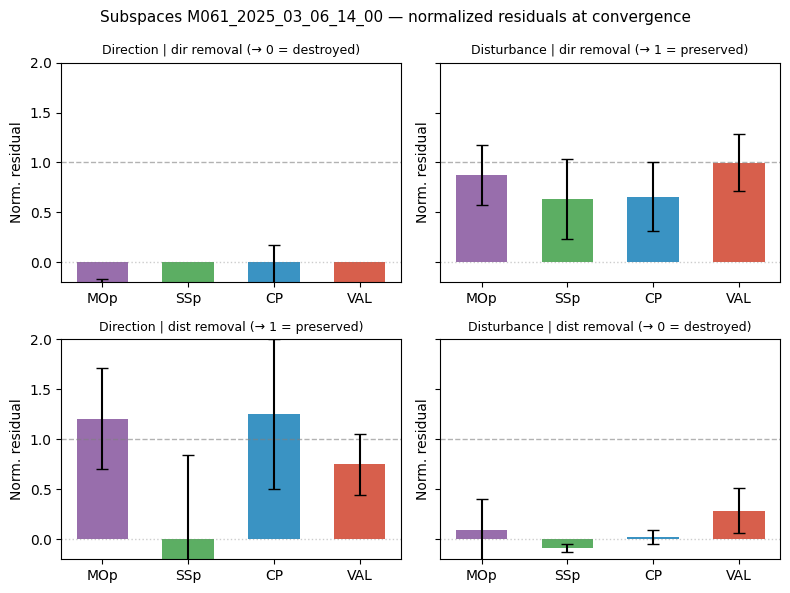

In [256]:
# ── Subspace separation summary ───────────────────────────────────────────────
# For each area, compute 4 normalized residuals at convergence:
#
#   norm_residual = (score_final - lower_bound) / (score_iter0 - lower_bound)
#
#   ~0 = fully destroyed   ~1 = fully preserved
#
#              | after dir removal | after dist removal |
#   direction  |   [0,0]  → ~0    |   [0,1]  → ~1      |
#   disturbance|   [1,0]  → ~1    |   [1,1]  → ~0      |

def norm_residual(scores, lb):
    """Normalise final iteration score to [0,1]: 0=destroyed, 1=preserved."""
    s0  = np.mean(scores[0])
    sf  = np.mean(scores[-1])
    lb0 = np.mean(lb[0]) if isinstance(lb, list) else lb
    denom = s0 - lb0
    if denom < 1e-9:
        return np.nan
    return (sf - lb0) / denom

def norm_residual_folds(scores, lb):
    """Per-fold normalized residuals — normalise by mean iter-0 and mean lb."""
    s0_folds = np.array(scores[0])
    sf_folds = np.array(scores[-1])
    lb0_mean = np.mean(lb[0]) if isinstance(lb, list) else lb
    denom    = np.mean(s0_folds) - lb0_mean
    if denom < 1e-9:
        return np.full(len(s0_folds), np.nan)
    return (sf_folds - lb0_mean) / denom

summary = {}
for area in Params.areas:
    res_dr = results_by_area[area]['dir_removal']
    res_di = results_by_area[area]['dist_removal']
    chance = results_by_area[area]['chance']

    summary[area] = {
        'dir_after_dir_removal' :  norm_residual(res_dr['dir'],  [chance]*len(res_dr['dir'])),
        'dist_after_dir_removal':  norm_residual(res_dr['dist'], res_dr['lb']),
        'dir_after_dist_removal':  norm_residual(res_di['dir'],  [chance]*len(res_di['dir'])),
        'dist_after_dist_removal': norm_residual(res_di['dist'], res_di['lb']),
        # per-fold versions for errorbars
        'dir_after_dir_removal_folds' :  norm_residual_folds(res_dr['dir'],  [chance]*len(res_dr['dir'])),
        'dist_after_dir_removal_folds':  norm_residual_folds(res_dr['dist'], res_dr['lb']),
        'dir_after_dist_removal_folds':  norm_residual_folds(res_di['dir'],  [chance]*len(res_di['dir'])),
        'dist_after_dist_removal_folds': norm_residual_folds(res_di['dist'], res_di['lb']),
    }

# Print table
header = f"{'Area':<6}  {'dir|dir-rem':>12}  {'dist|dir-rem':>13}  {'dir|dist-rem':>13}  {'dist|dist-rem':>14}"
print(header)
print('-' * len(header))
for area, m in summary.items():
    print(f"{area:<6}  {m['dir_after_dir_removal']:>12.2f}  "
          f"{m['dist_after_dir_removal']:>13.2f}  "
          f"{m['dir_after_dist_removal']:>13.2f}  "
          f"{m['dist_after_dist_removal']:>14.2f}")

# ── Plot: 2×2 heatmap-style bar chart ────────────────────────────────────────
areas  = list(summary.keys())
keys   = ['dir_after_dir_removal', 'dist_after_dir_removal',
          'dir_after_dist_removal', 'dist_after_dist_removal']
fold_keys = [k + '_folds' for k in keys]
titles = ['Direction | dir removal (→ 0 = destroyed)',
          'Disturbance | dir removal (→ 1 = preserved)',
          'Direction | dist removal (→ 1 = preserved)',
          'Disturbance | dist removal (→ 0 = destroyed)']

fig, axs = plt.subplots(2, 2, figsize=(8, 6), sharey=True)
axs = axs.flatten()

x = np.arange(len(areas))
for ax, key, fkey, title in zip(axs, keys, fold_keys, titles):
    vals   = [summary[a][key]  for a in areas]
    errs   = [np.std(summary[a][fkey]) for a in areas]
    colors_ = [getattr(colors, f'{a}_light') for a in areas]
    ax.bar(x, vals, color=colors_, width=0.6, zorder=2)
    ax.errorbar(x, vals, yerr=errs, fmt='none', color='k', capsize=4, lw=1.5, zorder=3)
    ax.axhline(1, color='gray', ls='--', lw=1, alpha=0.6)
    ax.axhline(0, color='gray', ls=':',  lw=1, alpha=0.4)
    ax.set_xticks(x); ax.set_xticklabels(areas)
    ax.set_ylim(-0.2, 2)
    ax.set_title(title, fontsize=9)
    ax.set_ylabel('Norm. residual')

plt.suptitle(f'Subspaces {SESSIONS[0]} — normalized residuals at convergence', fontsize=11)
plt.tight_layout()
plt.show()


## Exploratory stuff

Neurons: 156  |  PCs kept: 30  |  LDA axes: 11
Variance  population (156N):  16804.29
Variance  top-30 PCs:              6817.81  (40.6% of population)
Variance  potent (11 dims):         1200.43  (7.1% of population  |  17.6% of top-30 PCs)
Variance  null   (19 dims):        5617.38  (33.4% of population  |  82.4% of top-30 PCs)

Direction  train full / test full:  0.333 +/- 0.044
Direction  train full / test null:  0.035 +/- 0.030
Chance:                             0.083

disturb_sum  train full / test full:  R2 = 0.390 +/- 0.052
disturb_sum  train full / test null:  R2 = 0.409 +/- 0.082
disturb_sum  lower_bound train full -> shuffle test full:  R2 = 0.030 +/- 0.024


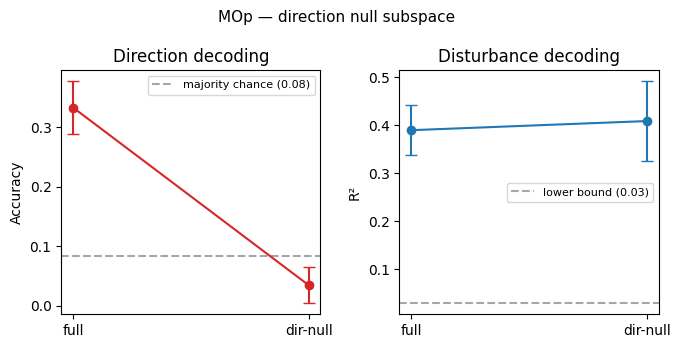

In [20]:
from sklearn.model_selection import StratifiedKFold, KFold

# ── Parameters ────────────────────────────────────────────────────────────────
origin_rank = 30
dir_window  = (200, 250)   # epoch for fitting LDA axes & direction decoding
dist_window = (200, 250)   # epoch for disturbance decoding
alpha_ridge = 0.01
n_splits    = 4
shuffle = True

# ── Data ──────────────────────────────────────────────────────────────────────
X_full  = np.stack(td_drop.MOp_rates_pca.values)[:, :, :origin_rank]
X_rates = np.concatenate(td_drop.MOp_rates.values)            # all neurons, all time
y_dir   = np.array(td_drop.values_Sol_direction.values.tolist())
y_dist  = td_drop.disturb_sum.values.astype(float)

_, _counts = np.unique(y_dir, return_counts=True)
chance  = _counts.max() / _counts.sum()   # majority class probability

# ── Fit LDA axes on direction window, compute null ────────────────────────────
X_dir_ep  = X_full[:, dir_window[0]:dir_window[1], :].mean(axis=1)
axes      = get_lda_axes(X_dir_ep, y_dir)
X_null    = np.array([iterative_null_projection(t, axes) for t in X_full])

X_dir_null_ep  = X_null[:, dir_window[0]:dir_window[1], :].mean(axis=1)
X_dist_ep      = X_full[:, dist_window[0]:dist_window[1], :].mean(axis=1)
X_dist_null_ep = X_null[:, dist_window[0]:dist_window[1], :].mean(axis=1)

# ── Diagnostics: variance ─────────────────────────────────────────────────────
cov          = np.cov(X_dir_ep.T)
var_total    = np.trace(cov)                                   # variance in top-origin_rank PCs
var_potent   = np.trace(axes.T @ cov @ axes)
P_null       = np.eye(origin_rank) - axes @ axes.T
var_null     = np.trace(P_null @ cov @ P_null)
var_pop      = np.trace(np.cov(X_rates.T))                     # total population variance

print(f'Neurons: {X_rates.shape[1]}  |  PCs kept: {origin_rank}  |  LDA axes: {axes.shape[1]}')
print(f'Variance  population ({X_rates.shape[1]}N):  {var_pop:.2f}')
print(f'Variance  top-{origin_rank} PCs:              {var_total:.2f}  ({var_total/var_pop*100:.1f}% of population)')
print(f'Variance  potent ({axes.shape[1]} dims):         {var_potent:.2f}  ({var_potent/var_pop*100:.1f}% of population  |  {var_potent/var_total*100:.1f}% of top-{origin_rank} PCs)')
print(f'Variance  null   ({origin_rank-axes.shape[1]} dims):        {var_null:.2f}  ({var_null/var_pop*100:.1f}% of population  |  {var_null/var_total*100:.1f}% of top-{origin_rank} PCs)')
print()

# ── Direction decoding ────────────────────────────────────────────────────────
cv_dir = StratifiedKFold(n_splits=n_splits, shuffle=shuffle)
dir_full, dir_null = [], []
for train_idx, test_idx in cv_dir.split(X_dir_ep, y_dir):
    clf = LinearDiscriminantAnalysis()
    clf.fit(X_dir_ep[train_idx], y_dir[train_idx])
    dir_full.append(clf.score(X_dir_ep[test_idx], y_dir[test_idx]))
    dir_null.append(clf.score(X_dir_null_ep[test_idx], y_dir[test_idx]))

print(f'Direction  train full / test full:  {np.mean(dir_full):.3f} +/- {np.std(dir_full):.3f}')
print(f'Direction  train full / test null:  {np.mean(dir_null):.3f} +/- {np.std(dir_null):.3f}')
print(f'Chance:                             {chance:.3f}')
print()

# ── Disturbance decoding ──────────────────────────────────────────────────────
rng     = np.random.default_rng(42)
cv_dist = KFold(n_splits=n_splits, shuffle=shuffle)
dist_full, dist_null, dist_lb = [], [], []
y_shuf = rng.permutation(y_dist)
for train_idx, test_idx in cv_dist.split(X_dist_ep):
    reg = Ridge(alpha_ridge)
    reg.fit(X_dist_ep[train_idx], y_dist[train_idx])
    dist_full.append(decode.custom_r2_func(y_dist[test_idx], reg.predict(X_dist_ep[test_idx])))
    dist_null.append(decode.custom_r2_func(y_dist[test_idx], reg.predict(X_dist_null_ep[test_idx])))
    dist_lb.append(decode.custom_r2_func(y_shuf[test_idx], reg.predict(X_dist_ep[test_idx])))

print(f'disturb_sum  train full / test full:  R2 = {np.mean(dist_full):.3f} +/- {np.std(dist_full):.3f}')
print(f'disturb_sum  train full / test null:  R2 = {np.mean(dist_null):.3f} +/- {np.std(dist_null):.3f}')
print(f'disturb_sum  lower_bound train full -> shuffle test full:  R2 = {np.mean(dist_lb):.3f} +/- {np.std(dist_lb):.3f}')

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axs = plt.subplots(1, 2, figsize=(7, 3.5))

axs[0].errorbar([0, 1], [np.mean(dir_full), np.mean(dir_null)],
                yerr=[np.std(dir_full), np.std(dir_null)],
                fmt='o-', color='tab:red', capsize=4)
axs[0].axhline(chance, color='gray', linestyle='--', alpha=0.7, label=f'majority chance ({chance:.2f})')
axs[0].set_xticks([0, 1])
axs[0].set_xticklabels(['full', 'dir-null'])
axs[0].set_ylabel('Accuracy')
axs[0].set_title('Direction decoding')
axs[0].legend(fontsize=8)

axs[1].errorbar([0, 1], [np.mean(dist_full), np.mean(dist_null)],
                yerr=[np.std(dist_full), np.std(dist_null)],
                fmt='o-', color='tab:blue', capsize=4)
axs[1].axhline(np.mean(dist_lb), color='gray', linestyle='--', alpha=0.7, label=f'lower bound ({np.mean(dist_lb):.2f})')
axs[1].set_xticks([0, 1])
axs[1].set_xticklabels(['full', 'dir-null'])
axs[1].set_ylabel('R²')
axs[1].set_title('Disturbance decoding')
axs[1].legend(fontsize=8)

plt.suptitle('MOp — direction null subspace', fontsize=11)
plt.tight_layout()
plt.show()


Disturbance axis: 1 dim
Variance  potent (1 dim):      145.09  (0.9% of population  |  2.1% of top-30 PCs)
Variance  null   (29 dims):  6672.71  (39.7% of population  |  97.9% of top-30 PCs)

Direction  train full / test full:       0.292 +/- 0.033
Direction  train full / test dist-null:  0.292 +/- 0.046
Chance:                                  0.083

disturb_sum  train full / test full:       R2 = 0.394 +/- 0.148
disturb_sum  train full / test dist-null:  R2 = 0.135 +/- 0.168
disturb_sum  lower bound (shuffled y):     R2 = 0.005 +/- 0.004


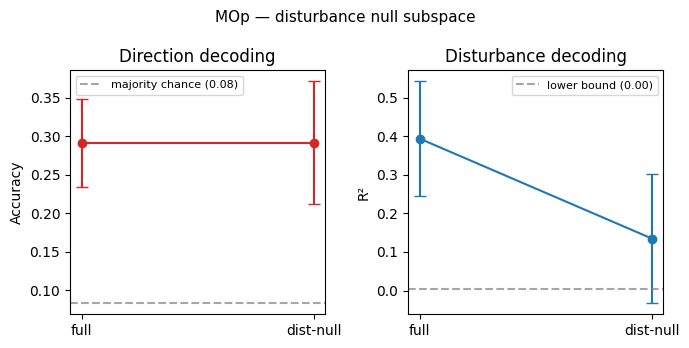

In [21]:
# ── Reverse: null to disturb_sum, test direction ──────────────────────────────
# Ridge gives 1 decoding axis (scalar target). Null is (N-1)-dimensional.

# Fit Ridge on disturbance window to get the disturbance axis
reg_dist  = Ridge(alpha_ridge)
reg_dist.fit(X_dist_ep, y_dist)
w_dist    = reg_dist.coef_.ravel()
w_dist    = w_dist / np.linalg.norm(w_dist)
axes_dist = w_dist[:, None]                  # (origin_rank, 1)

X_null_dist         = np.array([iterative_null_projection(t, axes_dist) for t in X_full])
X_dir_null_dist_ep  = X_null_dist[:, dir_window[0]:dir_window[1], :].mean(axis=1)
X_dist_null_dist_ep = X_null_dist[:, dist_window[0]:dist_window[1], :].mean(axis=1)

# ── Diagnostics: variance ─────────────────────────────────────────────────────
var_dist_potent = np.trace(axes_dist.T @ cov @ axes_dist)
P_null_dist     = np.eye(origin_rank) - axes_dist @ axes_dist.T
var_dist_null   = np.trace(P_null_dist @ cov @ P_null_dist)

print(f'Disturbance axis: 1 dim')
print(f'Variance  potent (1 dim):      {var_dist_potent:.2f}  ({var_dist_potent/var_pop*100:.1f}% of population  |  {var_dist_potent/var_total*100:.1f}% of top-{origin_rank} PCs)')
print(f'Variance  null   ({origin_rank-1} dims):  {var_dist_null:.2f}  ({var_dist_null/var_pop*100:.1f}% of population  |  {var_dist_null/var_total*100:.1f}% of top-{origin_rank} PCs)')
print()

# ── Direction decoding in disturbance-null ────────────────────────────────────
dir_full_r, dir_null_dist = [], []
for train_idx, test_idx in cv_dir.split(X_dir_ep, y_dir):
    clf = LinearDiscriminantAnalysis()
    clf.fit(X_dir_ep[train_idx], y_dir[train_idx])
    dir_full_r.append(clf.score(X_dir_ep[test_idx], y_dir[test_idx]))
    dir_null_dist.append(clf.score(X_dir_null_dist_ep[test_idx], y_dir[test_idx]))

print(f'Direction  train full / test full:       {np.mean(dir_full_r):.3f} +/- {scipy.stats.sem(dir_full_r):.3f}')
print(f'Direction  train full / test dist-null:  {np.mean(dir_null_dist):.3f} +/- {scipy.stats.sem(dir_null_dist):.3f}')
print(f'Chance:                                  {chance:.3f}')
print()

# ── Disturbance decoding in disturbance-null ──────────────────────────────────
y_shuf = rng.permutation(y_dist)
dist_full_r, dist_null_dist, dist_lb_r = [], [], []
for train_idx, test_idx in cv_dist.split(X_dist_ep):
    reg = Ridge(alpha_ridge)
    reg.fit(X_dist_ep[train_idx], y_dist[train_idx])
    dist_full_r.append(decode.custom_r2_func(y_dist[test_idx],  reg.predict(X_dist_ep[test_idx])))
    dist_null_dist.append(decode.custom_r2_func(y_dist[test_idx],  reg.predict(X_dist_null_dist_ep[test_idx])))
    dist_lb_r.append(decode.custom_r2_func(y_shuf[test_idx], reg.predict(X_dist_ep[test_idx])))

print(f'disturb_sum  train full / test full:       R2 = {np.mean(dist_full_r):.3f} +/- {np.std(dist_full_r):.3f}')
print(f'disturb_sum  train full / test dist-null:  R2 = {np.mean(dist_null_dist):.3f} +/- {np.std(dist_null_dist):.3f}')
print(f'disturb_sum  lower bound (shuffled y):     R2 = {np.mean(dist_lb_r):.3f} +/- {np.std(dist_lb_r):.3f}')

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axs = plt.subplots(1, 2, figsize=(7, 3.5))

axs[0].errorbar([0, 1], [np.mean(dir_full_r), np.mean(dir_null_dist)],
                yerr=[np.std(dir_full_r), np.std(dir_null_dist)],
                fmt='o-', color='tab:red', capsize=4)
axs[0].axhline(chance, color='gray', linestyle='--', alpha=0.7, label=f'majority chance ({chance:.2f})')
axs[0].set_xticks([0, 1])
axs[0].set_xticklabels(['full', 'dist-null'])
axs[0].set_ylabel('Accuracy')
axs[0].set_title('Direction decoding')
axs[0].legend(fontsize=8)

axs[1].errorbar([0, 1], [np.mean(dist_full_r), np.mean(dist_null_dist)],
                yerr=[np.std(dist_full_r), np.std(dist_null_dist)],
                fmt='o-', color='tab:blue', capsize=4)
axs[1].axhline(np.mean(dist_lb_r), color='gray', linestyle='--', alpha=0.7, label=f'lower bound ({np.mean(dist_lb_r):.2f})')
axs[1].set_xticks([0, 1])
axs[1].set_xticklabels(['full', 'dist-null'])
axs[1].set_ylabel('R²')
axs[1].set_title('Disturbance decoding')
axs[1].legend(fontsize=8)

plt.suptitle('MOp — disturbance null subspace', fontsize=11)
plt.tight_layout()
plt.show()


Iter 0  disturb R2 = 0.390  |  direction acc = 0.333  (full space)
Iter 1  disturb R2 = 0.191 +/- 0.059 (lb=0.011)  |  direction acc = 0.299 +/- 0.103 (chance=0.083)  |  var 97.2% of top-30PCs  /  66.0% of pop
Iter 2  disturb R2 = 0.223 +/- 0.105 (lb=0.006)  |  direction acc = 0.306 +/- 0.034 (chance=0.083)  |  var 93.7% of top-30PCs  /  63.6% of pop
Iter 3  disturb R2 = 0.078 +/- 0.038 (lb=0.010)  |  direction acc = 0.306 +/- 0.034 (chance=0.083)  |  var 93.7% of top-30PCs  /  63.6% of pop
Iter 4  disturb R2 = 0.072 +/- 0.028 (lb=0.006)  |  direction acc = 0.278 +/- 0.044 (chance=0.083)  |  var 90.9% of top-30PCs  /  61.7% of pop
Iter 5  disturb R2 = 0.028 +/- 0.036 (lb=0.006)  |  direction acc = 0.306 +/- 0.071 (chance=0.083)  |  var 90.9% of top-30PCs  /  61.7% of pop


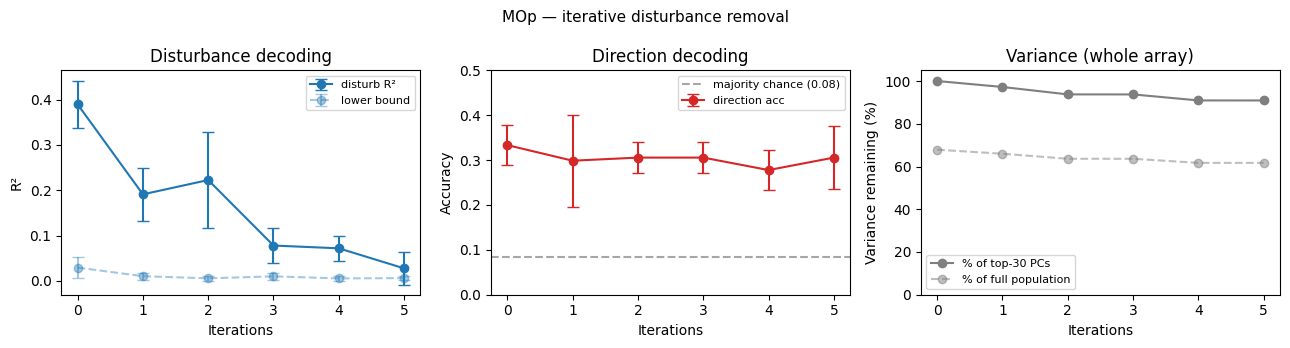

Var (% top-30 PCs): [100.0, 97.2, 93.7, 93.7, 90.9, 90.9]
Var (% population):     [67.9, 66.0, 63.6, 63.6, 61.7, 61.7]


In [22]:
# ── Iterative disturbance removal — track disturb + direction at each step ────
n_iter  = 5
y_shuf  = rng.permutation(y_dist)
X_iter  = X_full.copy()

# Baseline variance over the whole array (all trials × all time points)
var_base_pca = np.trace(np.cov(X_full.reshape(-1, origin_rank).T))  # top-origin_rank PCs

# Storage: iter 0 = full space
all_dist_mean = [np.mean(dist_full)];  all_dist_std = [np.std(dist_full)]
all_lb_mean   = [np.mean(dist_lb)];    all_lb_std   = [np.std(dist_lb)]
all_dir_mean  = [np.mean(dir_full)];   all_dir_std  = [np.std(dir_full)]
all_var_pca   = [1.0]   # fraction of origin_rank space
all_var_pop   = [var_base_pca / var_pop]   # fraction of full population

print(f'Iter 0  disturb R2 = {all_dist_mean[0]:.3f}  |  direction acc = {all_dir_mean[0]:.3f}  (full space)')

for i in range(n_iter):
    X_iter_dist_ep = X_iter[:, dist_window[0]:dist_window[1], :].mean(axis=1)
    X_iter_dir_ep  = X_iter[:, dir_window[0]:dir_window[1],  :].mean(axis=1)

    reg_iter = Ridge(alpha_ridge)
    reg_iter.fit(X_iter_dist_ep, y_dist)
    w_iter  = reg_iter.coef_.ravel()
    w_iter  = w_iter / np.linalg.norm(w_iter)
    X_iter  = np.array([iterative_null_projection(t, w_iter[:, None]) for t in X_iter])

    X_iter_dist_ep = X_iter[:, dist_window[0]:dist_window[1], :].mean(axis=1)
    X_iter_dir_ep  = X_iter[:, dir_window[0]:dir_window[1],  :].mean(axis=1)

    # Variance over whole array
    var_i = np.trace(np.cov(X_iter.reshape(-1, origin_rank).T))
    all_var_pca.append(var_i / var_base_pca)
    all_var_pop.append(var_i / var_pop)

    dist_null_i, dist_lb_i = [], []
    for train_idx, test_idx in cv_dist.split(X_iter_dist_ep):
        reg = Ridge(alpha_ridge)
        reg.fit(X_iter_dist_ep[train_idx], y_dist[train_idx])
        dist_null_i.append(decode.custom_r2_func(y_dist[test_idx], reg.predict(X_iter_dist_ep[test_idx])))
        dist_lb_i.append(  decode.custom_r2_func(y_shuf[test_idx], reg.predict(X_iter_dist_ep[test_idx])))

    dir_null_i = []
    for train_idx, test_idx in cv_dir.split(X_iter_dir_ep, y_dir):
        clf = LinearDiscriminantAnalysis()
        clf.fit(X_iter_dir_ep[train_idx], y_dir[train_idx])
        dir_null_i.append(clf.score(X_iter_dir_ep[test_idx], y_dir[test_idx]))

    all_dist_mean.append(np.mean(dist_null_i));  all_dist_std.append(np.std(dist_null_i))
    all_lb_mean.append(np.mean(dist_lb_i));      all_lb_std.append(np.std(dist_lb_i))
    all_dir_mean.append(np.mean(dir_null_i));    all_dir_std.append(np.std(dir_null_i))

    print(f'Iter {i+1}  '
          f'disturb R2 = {all_dist_mean[-1]:.3f} +/- {all_dist_std[-1]:.3f} (lb={all_lb_mean[-1]:.3f})  |  '
          f'direction acc = {all_dir_mean[-1]:.3f} +/- {all_dir_std[-1]:.3f} (chance={chance:.3f})  |  '
          f'var {all_var_pca[-1]*100:.1f}% of top-{origin_rank}PCs  /  {all_var_pop[-1]*100:.1f}% of pop')

# ── Plot ─────────────────────────────────────────────────────────────────────
iters = np.arange(n_iter + 1)
fig, axs = plt.subplots(1, 3, figsize=(13, 3.5))

axs[0].errorbar(iters, all_dist_mean, yerr=all_dist_std, fmt='o-', color='tab:blue', capsize=4, label='disturb R²')
axs[0].errorbar(iters, all_lb_mean,   yerr=all_lb_std,   fmt='o--', color='tab:blue', alpha=0.4, capsize=4, label='lower bound')
axs[0].set_xlabel('Iterations'); axs[0].set_ylabel('R²')
axs[0].set_title('Disturbance decoding'); axs[0].legend(fontsize=8)

axs[1].errorbar(iters, all_dir_mean, yerr=all_dir_std, fmt='o-', color='tab:red', capsize=4, label='direction acc')
axs[1].axhline(chance, color='gray', linestyle='--', alpha=0.7, label=f'majority chance ({chance:.2f})')
axs[1].set_xlabel('Iterations'); axs[1].set_ylabel('Accuracy')
axs[1].set_title('Direction decoding'); axs[1].legend(fontsize=8); axs[1].set_ylim(0, 0.5)

axs[2].plot(iters, [v*100 for v in all_var_pca], 'o-', color='tab:gray',  label=f'% of top-{origin_rank} PCs')
axs[2].plot(iters, [v*100 for v in all_var_pop], 'o--', color='tab:gray', alpha=0.5, label='% of full population')
axs[2].set_xlabel('Iterations'); axs[2].set_ylabel('Variance remaining (%)')
axs[2].set_title('Variance (whole array)'); axs[2].set_ylim(0, 105); axs[2].legend(fontsize=8)

plt.suptitle('MOp — iterative disturbance removal', fontsize=11)
plt.tight_layout()
plt.show()
print(f'Var (% top-{origin_rank} PCs): {[round(v*100,1) for v in all_var_pca]}')
print(f'Var (% population):     {[round(v*100,1) for v in all_var_pop]}')


Iter 0  direction acc = 0.333  |  disturb R2 = 0.390  (full space)
Iter 1  direction acc = 0.111 +/- 0.039 (chance=0.083)  |  disturb R2 = 0.447 +/- 0.078 (lb=0.023)  |  var 73.9% of top-30PCs  /  50.2% of pop
Iter 2  direction acc = 0.090 +/- 0.023 (chance=0.083)  |  disturb R2 = 0.475 +/- 0.109 (lb=0.017)  |  var 49.3% of top-30PCs  /  33.4% of pop
Iter 3  direction acc = 0.076 +/- 0.030 (chance=0.083)  |  disturb R2 = 0.482 +/- 0.059 (lb=0.030)  |  var 44.3% of top-30PCs  /  30.0% of pop
Iter 4  direction acc = 0.104 +/- 0.012 (chance=0.083)  |  disturb R2 = 0.464 +/- 0.027 (lb=0.011)  |  var 42.0% of top-30PCs  /  28.5% of pop
Iter 5  direction acc = 0.083 +/- 0.034 (chance=0.083)  |  disturb R2 = 0.470 +/- 0.095 (lb=0.014)  |  var 37.5% of top-30PCs  /  25.4% of pop


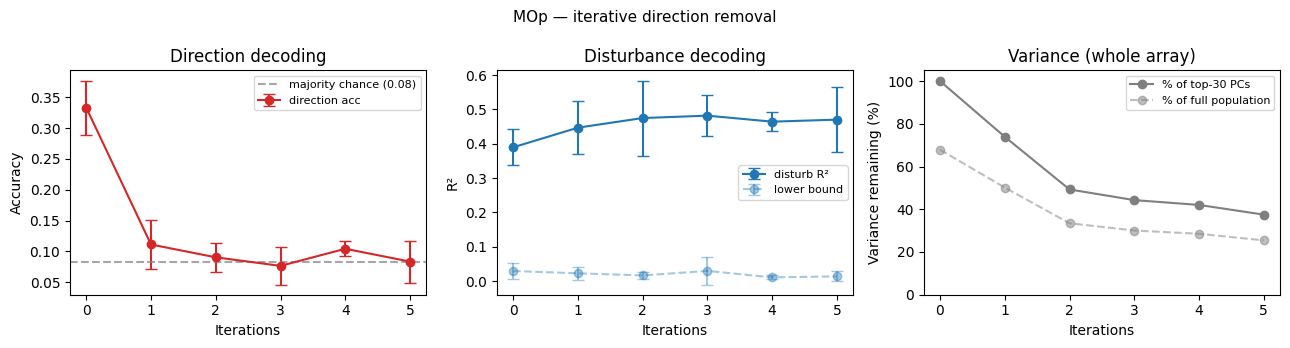

Var (% top-30 PCs): [100.0, 73.9, 49.3, 44.3, 42.0, 37.5]
Var (% population):     [67.9, 50.2, 33.4, 30.0, 28.5, 25.4]


In [23]:
# ── Iterative direction removal — track direction + disturb at each step ──────
n_iter  = 5
y_shuf  = rng.permutation(y_dist)
X_iter  = X_full.copy()

# Baseline variance over the whole array (all trials × all time points)
var_base_pca = np.trace(np.cov(X_full.reshape(-1, origin_rank).T))  # top-origin_rank PCs

# Storage: iter 0 = full space
all_dir_mean  = [np.mean(dir_full)];   all_dir_std  = [np.std(dir_full)]
all_dist_mean = [np.mean(dist_full)];  all_dist_std = [np.std(dist_full)]
all_lb_mean   = [np.mean(dist_lb)];    all_lb_std   = [np.std(dist_lb)]
all_var_pca   = [1.0]
all_var_pop   = [var_base_pca / var_pop]

print(f'Iter 0  direction acc = {all_dir_mean[0]:.3f}  |  disturb R2 = {all_dist_mean[0]:.3f}  (full space)')

for i in range(n_iter):
    X_iter_dir_ep  = X_iter[:, dir_window[0]:dir_window[1],  :].mean(axis=1)
    X_iter_dist_ep = X_iter[:, dist_window[0]:dist_window[1],:].mean(axis=1)

    ax_iter = get_lda_axes(X_iter_dir_ep, y_dir)
    X_iter  = np.array([iterative_null_projection(t, ax_iter) for t in X_iter])

    X_iter_dir_ep  = X_iter[:, dir_window[0]:dir_window[1],  :].mean(axis=1)
    X_iter_dist_ep = X_iter[:, dist_window[0]:dist_window[1],:].mean(axis=1)

    # Variance over whole array
    var_i = np.trace(np.cov(X_iter.reshape(-1, origin_rank).T))
    all_var_pca.append(var_i / var_base_pca)
    all_var_pop.append(var_i / var_pop)

    dir_null_i = []
    for train_idx, test_idx in cv_dir.split(X_iter_dir_ep, y_dir):
        clf = LinearDiscriminantAnalysis()
        clf.fit(X_iter_dir_ep[train_idx], y_dir[train_idx])
        dir_null_i.append(clf.score(X_iter_dir_ep[test_idx], y_dir[test_idx]))

    dist_null_i, dist_lb_i = [], []
    for train_idx, test_idx in cv_dist.split(X_iter_dist_ep):
        reg = Ridge(alpha_ridge)
        reg.fit(X_iter_dist_ep[train_idx], y_dist[train_idx])
        dist_null_i.append(decode.custom_r2_func(y_dist[test_idx], reg.predict(X_iter_dist_ep[test_idx])))
        dist_lb_i.append(  decode.custom_r2_func(y_shuf[test_idx], reg.predict(X_iter_dist_ep[test_idx])))

    all_dir_mean.append(np.mean(dir_null_i));    all_dir_std.append(np.std(dir_null_i))
    all_dist_mean.append(np.mean(dist_null_i));  all_dist_std.append(np.std(dist_null_i))
    all_lb_mean.append(np.mean(dist_lb_i));      all_lb_std.append(np.std(dist_lb_i))

    print(f'Iter {i+1}  '
          f'direction acc = {all_dir_mean[-1]:.3f} +/- {all_dir_std[-1]:.3f} (chance={chance:.3f})  |  '
          f'disturb R2 = {all_dist_mean[-1]:.3f} +/- {all_dist_std[-1]:.3f} (lb={all_lb_mean[-1]:.3f})  |  '
          f'var {all_var_pca[-1]*100:.1f}% of top-{origin_rank}PCs  /  {all_var_pop[-1]*100:.1f}% of pop')

# ── Plot ─────────────────────────────────────────────────────────────────────
iters = np.arange(n_iter + 1)
fig, axs = plt.subplots(1, 3, figsize=(13, 3.5))

axs[0].errorbar(iters, all_dir_mean, yerr=all_dir_std, fmt='o-', color='tab:red', capsize=4, label='direction acc')
axs[0].axhline(chance, color='gray', linestyle='--', alpha=0.7, label=f'majority chance ({chance:.2f})')
axs[0].set_xlabel('Iterations'); axs[0].set_ylabel('Accuracy')
axs[0].set_title('Direction decoding'); axs[0].legend(fontsize=8)

axs[1].errorbar(iters, all_dist_mean, yerr=all_dist_std, fmt='o-', color='tab:blue', capsize=4, label='disturb R²')
axs[1].errorbar(iters, all_lb_mean,   yerr=all_lb_std,   fmt='o--', color='tab:blue', alpha=0.4, capsize=4, label='lower bound')
axs[1].set_xlabel('Iterations'); axs[1].set_ylabel('R²')
axs[1].set_title('Disturbance decoding'); axs[1].legend(fontsize=8)

axs[2].plot(iters, [v*100 for v in all_var_pca], 'o-', color='tab:gray',  label=f'% of top-{origin_rank} PCs')
axs[2].plot(iters, [v*100 for v in all_var_pop], 'o--', color='tab:gray', alpha=0.5, label='% of full population')
axs[2].set_xlabel('Iterations'); axs[2].set_ylabel('Variance remaining (%)')
axs[2].set_title('Variance (whole array)'); axs[2].set_ylim(0, 105); axs[2].legend(fontsize=8)

plt.suptitle('MOp — iterative direction removal', fontsize=11)
plt.tight_layout()
plt.show()
print(f'Var (% top-{origin_rank} PCs): {[round(v*100,1) for v in all_var_pca]}')
print(f'Var (% population):     {[round(v*100,1) for v in all_var_pop]}')


Dir removal  angles: [86.1, 78.0, 40.2, 31.4, 63.7, 72.1]
Dist removal angles: [86.1, 79.5, 25.5, 81.8, 82.8, 86.4]


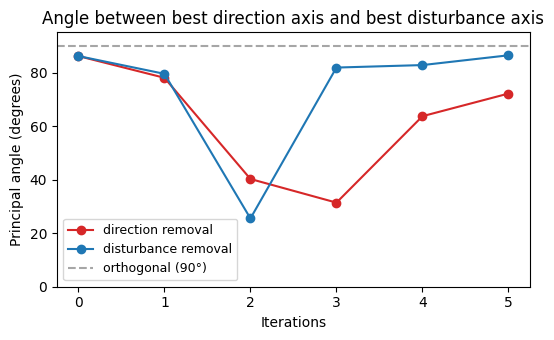

In [19]:
# ── Principal angles: direction axis vs disturbance axis across iterations ────
# Re-runs direction/disturbance removal from scratch, tracking the angle between
# the best direction axis (LDA scalings_[:,0]) and the best disturbance
# axis (Ridge coef_ direction) at each step.

def best_dir_axis(X_ep, y):
    lda = LinearDiscriminantAnalysis()
    lda.fit(X_ep, y)
    w = lda.scalings_[:, 0]
    return w / np.linalg.norm(w)

def best_dist_axis(X_ep, y, alpha):
    reg = Ridge(alpha)
    reg.fit(X_ep, y)
    w = reg.coef_.ravel()
    return w / np.linalg.norm(w)

n_iter_pa   = 5
X_iter_dir  = X_full.copy()
X_iter_dist = X_full.copy()

angles_dir_removal  = []   # angle while removing direction axes
angles_dist_removal = []   # angle while removing disturbance axis

for i in range(n_iter_pa + 1):
    X_dir_ep  = X_iter_dir[:, dir_window[0]:dir_window[1], :].mean(axis=1)
    X_dist_ep = X_iter_dir[:, dist_window[0]:dist_window[1], :].mean(axis=1)
    w_dir  = best_dir_axis(X_dir_ep, y_dir)
    w_dist = best_dist_axis(X_dist_ep, y_dist, alpha_ridge)
    angle  = np.degrees(scipy.linalg.subspace_angles(w_dir[:, None], w_dist[:, None])[0])
    angles_dir_removal.append(angle)
    if i < n_iter_pa:
        ax_iter    = get_lda_axes(X_dir_ep, y_dir)
        X_iter_dir = np.array([iterative_null_projection(t, ax_iter) for t in X_iter_dir])

for i in range(n_iter_pa + 1):
    X_dir_ep  = X_iter_dist[:, dir_window[0]:dir_window[1], :].mean(axis=1)
    X_dist_ep = X_iter_dist[:, dist_window[0]:dist_window[1], :].mean(axis=1)
    w_dir  = best_dir_axis(X_dir_ep, y_dir)
    w_dist = best_dist_axis(X_dist_ep, y_dist, alpha_ridge)
    angle  = np.degrees(scipy.linalg.subspace_angles(w_dir[:, None], w_dist[:, None])[0])
    angles_dist_removal.append(angle)
    if i < n_iter_pa:
        w_d         = best_dist_axis(X_dist_ep, y_dist, alpha_ridge)
        X_iter_dist = np.array([iterative_null_projection(t, w_d[:, None]) for t in X_iter_dist])

print('Dir removal  angles:', [round(a, 1) for a in angles_dir_removal])
print('Dist removal angles:', [round(a, 1) for a in angles_dist_removal])

# ── Plot ──────────────────────────────────────────────────────────────────────
iters = np.arange(n_iter_pa + 1)
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(iters, angles_dir_removal,  'o-', color='tab:red',  label='direction removal')
ax.plot(iters, angles_dist_removal, 'o-', color='tab:blue', label='disturbance removal')
ax.axhline(90, color='gray', linestyle='--', alpha=0.7, label='orthogonal (90°)')
ax.set_xlabel('Iterations')
ax.set_ylabel('Principal angle (degrees)')
ax.set_title('Angle between best direction axis and best disturbance axis')
ax.set_ylim(0, 95)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## Time point removal

Peak direction full:  0.159 at t=0.24s
Peak disturbance full: 0.409 at t=0.42s
Min var remaining: 33.1% of window / 11.8% of pop


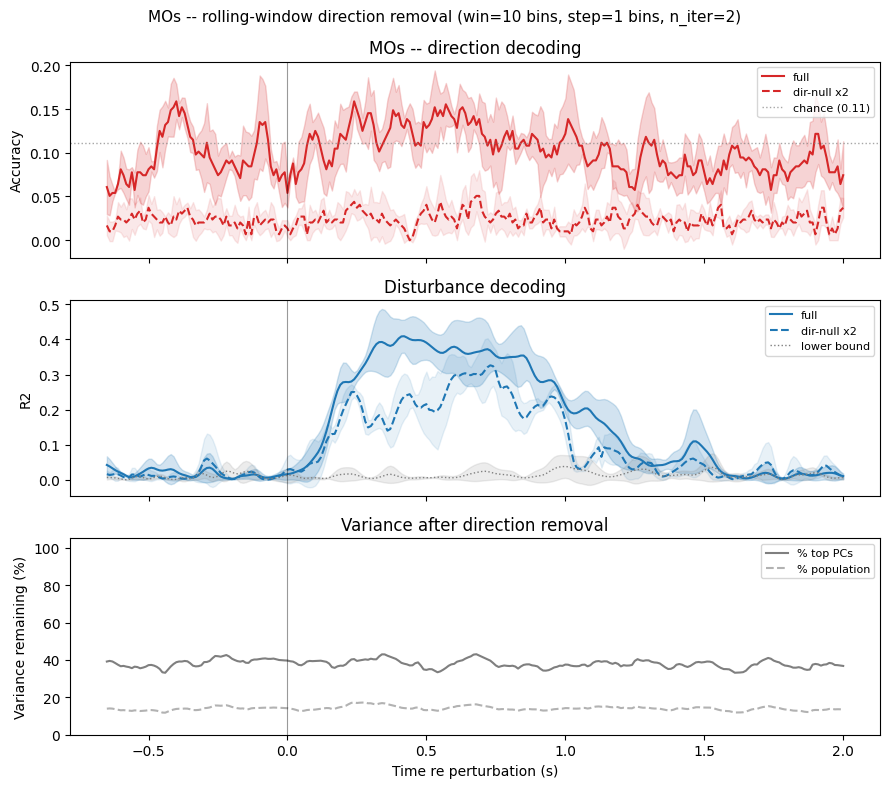

In [18]:
# ── Rolling-window direction removal ─────────────────────────────────────────
# For each window of win_size bins:
#   1. Epoch = mean over window → (n_trials, N)
#   2. Iteratively fit LDA → direction axes, compute null projection (n_iter times)
#   3. CV-decode direction (train-null/test-null) and disturbance (train-null/test-null)
#      from full and null epoch
# Gives a time-resolved picture of direction/disturbance separation.

area      = 'MOs'
win_size  = 10       # bins (30 ms)
step      = 1       # stride in bins
t_start   = 125     # bin index start  (relative to trial start, not sol_on)
t_end     = 400     # bin index end
n_iter    = 2       # number of iterative direction-axis removals
y_dir   = np.array(td_drop.values_Sol_direction.values.tolist())
y_dist  = td_drop.disturb_sum.values.astype(float)
rng     = np.random.default_rng(42)
n_splits = 4
shuffle = False
cv_dir = StratifiedKFold(n_splits=n_splits, shuffle=shuffle)
cv_dist = KFold(n_splits=n_splits, shuffle=shuffle)
alpha_ridge = 0.01

_, _counts = np.unique(y_dir, return_counts=True)
chance  = _counts.max() / _counts.sum()   # majority class probability
pc_dict = {
    "MOp": 30,
    "SSp": 25,
    "CP": 30,
    "VAL": 50,
    "MOs": 30
}
X_full_a  = np.stack(td_drop[f'{area}_rates_pca'].values)[:, :, :pc_dict[area]]
X_rates_a = np.concatenate(td_drop[f'{area}_rates'].values)
var_pop_a = np.trace(np.cov(X_rates_a.T))

y_shuf_t  = rng.permutation(y_dist)

win_starts = np.arange(t_start, t_end - win_size + 1, step)
times_s    = (win_starts + win_size - 200) * 0.01  # seconds re sol_on

dir_full_m,  dir_full_s  = [], []
dir_null_m,  dir_null_s  = [], []
dist_full_m, dist_full_s = [], []
dist_null_m, dist_null_s = [], []
dist_lb_m,   dist_lb_s   = [], []
var_frac_pca = []
var_frac_pop = []

for t in win_starts:
    X_win  = X_full_a[:, t:t+win_size, :].mean(axis=1)   # (n_trials, N)

    # iterative direction removal
    X_null = X_win.copy()
    for _ in range(n_iter):
        axes   = get_lda_axes(X_null, y_dir)
        P_null = np.eye(pc_dict[area]) - axes @ axes.T
        X_null = X_null @ P_null

    # variance diagnostics
    var_win    = np.trace(np.cov(X_win.T))
    var_null_w = np.trace(np.cov(X_null.T))
    var_frac_pca.append(var_null_w / var_win)
    var_frac_pop.append(var_null_w / var_pop_a)

    # direction: train-null / test-null
    dir_f, dir_n = [], []
    for tr, te in cv_dir.split(X_win, y_dir):
        clf_f = LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto')
        clf_f.fit(X_win[tr],  y_dir[tr])
        dir_f.append(clf_f.score(X_win[te],  y_dir[te]))
        clf_n = LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto')
        clf_n.fit(X_null[tr], y_dir[tr])
        dir_n.append(clf_n.score(X_null[te], y_dir[te]))

    # disturbance: train-null / test-null
    dist_f, dist_n, dist_lb = [], [], []
    for tr, te in cv_dist.split(X_win):
        reg_f = Ridge(alpha_ridge); reg_f.fit(X_win[tr],  y_dist[tr])
        reg_n = Ridge(alpha_ridge); reg_n.fit(X_null[tr], y_dist[tr])
        dist_f.append( decode.custom_r2_func(y_dist[te],   reg_f.predict(X_win[te])))
        dist_n.append( decode.custom_r2_func(y_dist[te],   reg_n.predict(X_null[te])))
        dist_lb.append(decode.custom_r2_func(y_shuf_t[te], reg_f.predict(X_win[te])))

    dir_full_m.append(np.mean(dir_f));   dir_full_s.append(np.std(dir_f))
    dir_null_m.append(np.mean(dir_n));   dir_null_s.append(np.std(dir_n))
    dist_full_m.append(np.mean(dist_f)); dist_full_s.append(np.std(dist_f))
    dist_null_m.append(np.mean(dist_n)); dist_null_s.append(np.std(dist_n))
    dist_lb_m.append(np.mean(dist_lb));  dist_lb_s.append(np.std(dist_lb))

dir_full_m  = np.array(dir_full_m);  dir_full_s  = np.array(dir_full_s)
dir_null_m  = np.array(dir_null_m);  dir_null_s  = np.array(dir_null_s)
dist_full_m = np.array(dist_full_m); dist_full_s = np.array(dist_full_s)
dist_null_m = np.array(dist_null_m); dist_null_s = np.array(dist_null_s)
dist_lb_m   = np.array(dist_lb_m);   dist_lb_s   = np.array(dist_lb_s)
var_frac_pca = np.array(var_frac_pca)
var_frac_pop = np.array(var_frac_pop)

print(f'Peak direction full:  {dir_full_m.max():.3f} at t={times_s[dir_full_m.argmax()]:.2f}s')
print(f'Peak disturbance full: {dist_full_m.max():.3f} at t={times_s[dist_full_m.argmax()]:.2f}s')
print(f'Min var remaining: {var_frac_pca.min()*100:.1f}% of window / {var_frac_pop.min()*100:.1f}% of pop')

# ── Plot ──────────────────────────────────────────────────────────────────────
c_area  = getattr(colors, area)
c_light = getattr(colors, f'{area}_light')

fig, axs = plt.subplots(3, 1, figsize=(9, 8), sharex=True)

# Direction
axs[0].fill_between(times_s, dir_full_m - dir_full_s, dir_full_m + dir_full_s,
                    color='tab:red', alpha=0.2)
axs[0].fill_between(times_s, dir_null_m - dir_null_s, dir_null_m + dir_null_s,
                    color='tab:red', alpha=0.1)
axs[0].plot(times_s, dir_full_m, color='tab:red',          lw=1.5, label='full')
axs[0].plot(times_s, dir_null_m, color='tab:red', ls='--', lw=1.5, label=f'dir-null x{n_iter}')
axs[0].axhline(chance, color='gray', ls=':', lw=1, alpha=0.7, label=f'chance ({chance:.2f})')
axs[0].axvline(0, color='k', lw=0.8, alpha=0.4)
axs[0].set_ylabel('Accuracy'); axs[0].set_title(f'{area} -- direction decoding')
axs[0].legend(fontsize=8)

# Disturbance
axs[1].fill_between(times_s, dist_full_m - dist_full_s, dist_full_m + dist_full_s,
                    color='tab:blue', alpha=0.2)
axs[1].fill_between(times_s, dist_null_m - dist_null_s, dist_null_m + dist_null_s,
                    color='tab:blue', alpha=0.1)
axs[1].plot(times_s, dist_full_m, color='tab:blue',          lw=1.5, label='full')
axs[1].plot(times_s, dist_null_m, color='tab:blue', ls='--', lw=1.5, label=f'dir-null x{n_iter}')
axs[1].fill_between(times_s, dist_lb_m - dist_lb_s, dist_lb_m + dist_lb_s,
                    color='gray', alpha=0.15)
axs[1].plot(times_s, dist_lb_m, color='gray', ls=':', lw=1, label='lower bound')
axs[1].axvline(0, color='k', lw=0.8, alpha=0.4)
axs[1].set_ylabel('R2'); axs[1].set_title('Disturbance decoding')
axs[1].legend(fontsize=8)

# Variance
axs[2].plot(times_s, var_frac_pca * 100, color='tab:gray',          lw=1.5, label=f'% top PCs')
axs[2].plot(times_s, var_frac_pop * 100, color='tab:gray', ls='--', lw=1.5, alpha=0.6, label='% population')
axs[2].axvline(0, color='k', lw=0.8, alpha=0.4)
axs[2].set_ylabel('Variance remaining (%)'); axs[2].set_ylim(0, 105)
axs[2].set_xlabel('Time re perturbation (s)')
axs[2].set_title('Variance after direction removal'); axs[2].legend(fontsize=8)

plt.suptitle(f'{area} -- rolling-window direction removal (win={win_size} bins, step={step} bins, n_iter={n_iter})', fontsize=11)
plt.tight_layout()
plt.show()
